3. DATA LOADING & EXPLORATION

3.1 Load Dataset B (Primary)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report
import joblib

In [2]:
!pip install flask flask_cors joblib numpy pandas

In [3]:
# import sys
# import os
# # добавляем РОДИТЕЛЬСКУЮ папку (ml)
# sys.path.append(os.path.abspath(".."))

# import ml_service
# import importlib
# importlib.reload(ml_service)

# # Привязываем переменные
# preprocess_user_input = ml_service.preprocess_user_input
# scaler = ml_service.scaler
# best_model = ml_service.regression_model
# clf_model = ml_service.classification_model
# label_encoder = ml_service.label_encoder
# feature_names = ml_service.feature_names



In [4]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

In [5]:
# Load Dataset B
import os

# Путь относительно корня проекта
data_path = '../human_cognitive_performance.csv' 

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Файл загружен локально")
else:
    print("Файл не найден!")

print(df.head())
print(df.shape)
print("="*60) 
print("DATASET B: HUMAN COGNITIVE PERFORMANCE")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nBasic statistics:\n{df.describe()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


Файл загружен локально
  User_ID  Age  Gender  Sleep_Duration  Stress_Level       Diet_Type  \
0      U1   57  Female             6.5             3  Non-Vegetarian   
1      U2   39  Female             7.6             9  Non-Vegetarian   
2      U3   26    Male             8.2             6      Vegetarian   
3      U4   32    Male             7.8             9      Vegetarian   
4      U5   50    Male             9.7             2  Non-Vegetarian   

   Daily_Screen_Time Exercise_Frequency  Caffeine_Intake  Reaction_Time  \
0                6.5             Medium               41         583.33   
1               10.8               High              214         368.24   
2                5.7                Low              429         445.21   
3                8.3                Low              464         286.33   
4               11.3             Medium              365         237.65   

   Memory_Test_Score  Cognitive_Score  AI_Predicted_Score  
0                 65            3

3.2 Exploratory Data Analysis (EDA)

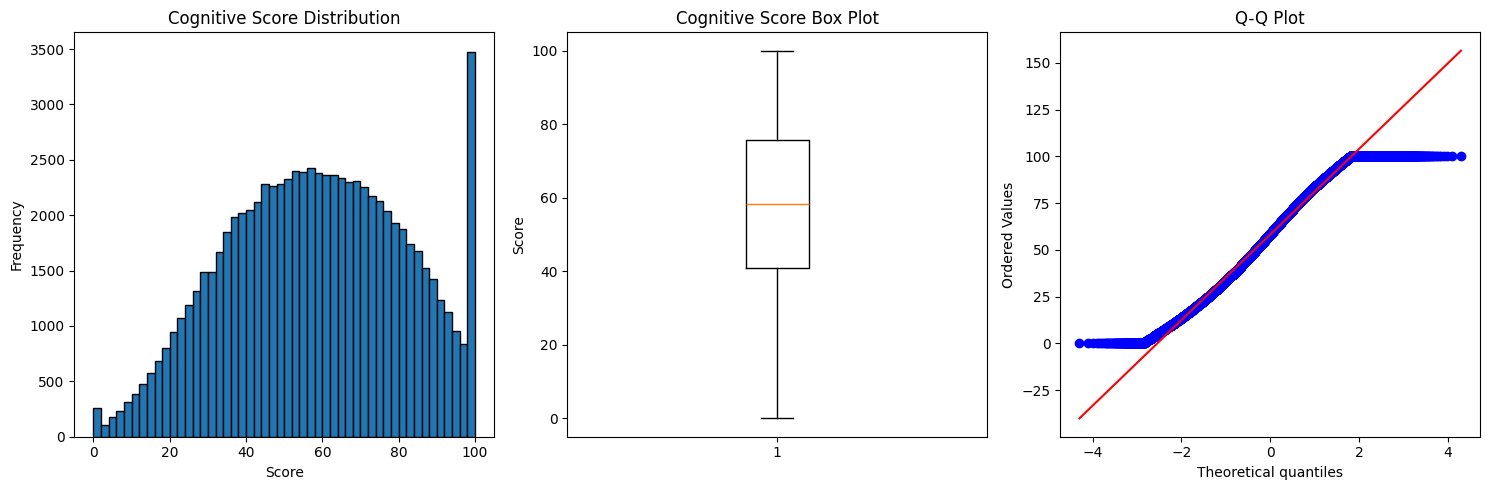

Cognitive Score Statistics:
Mean: 58.17
Median: 58.36
Std: 23.06
Min: 0.00
Max: 100.00
Skewness: -0.09


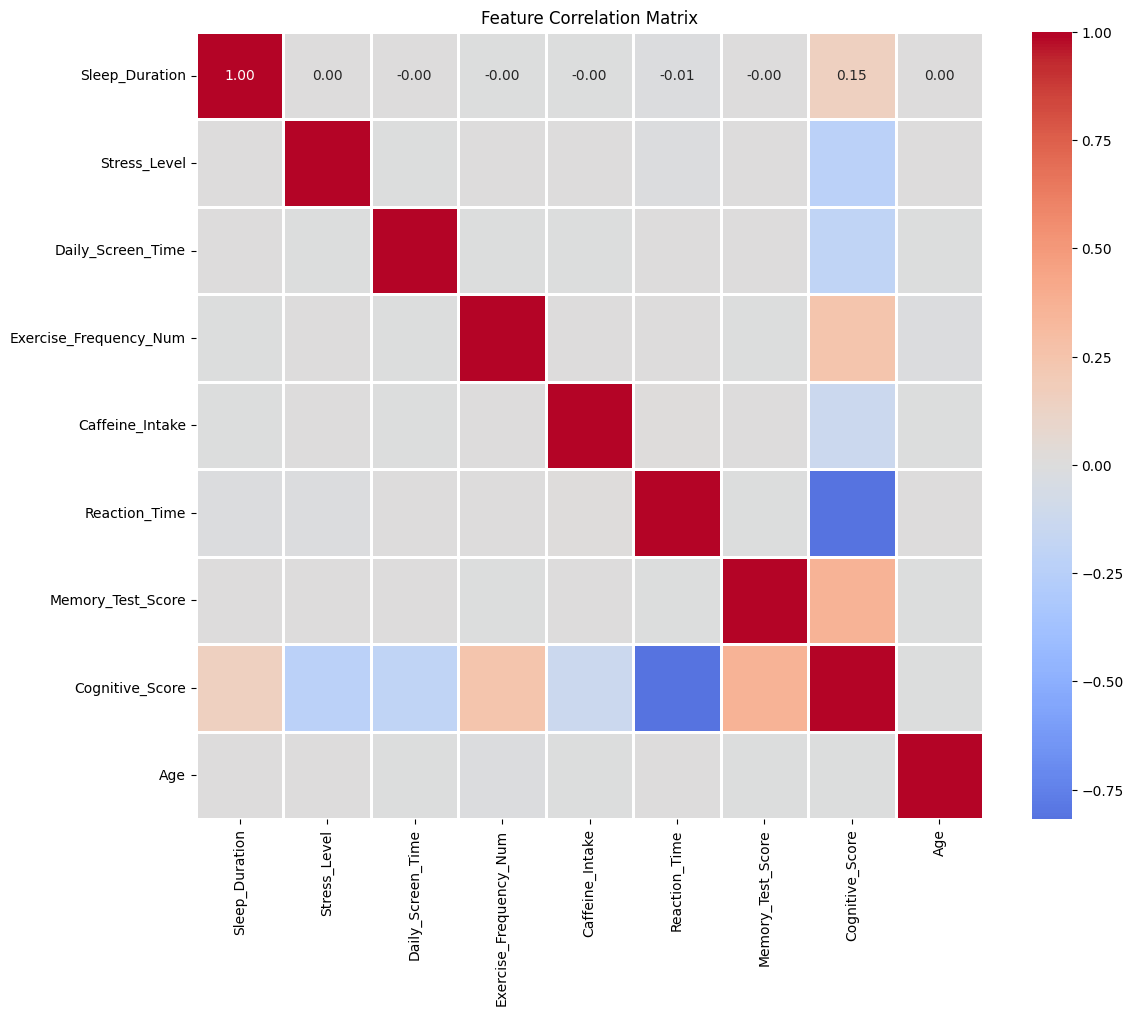


🎯 Correlations with Cognitive Score:
Cognitive_Score           1.000000
Memory_Test_Score         0.363894
Exercise_Frequency_Num    0.242011
Sleep_Duration            0.150595
Age                      -0.005976
Caffeine_Intake          -0.122862
Daily_Screen_Time        -0.198515
Stress_Level             -0.227639
Reaction_Time            -0.818470
Name: Cognitive_Score, dtype: float64


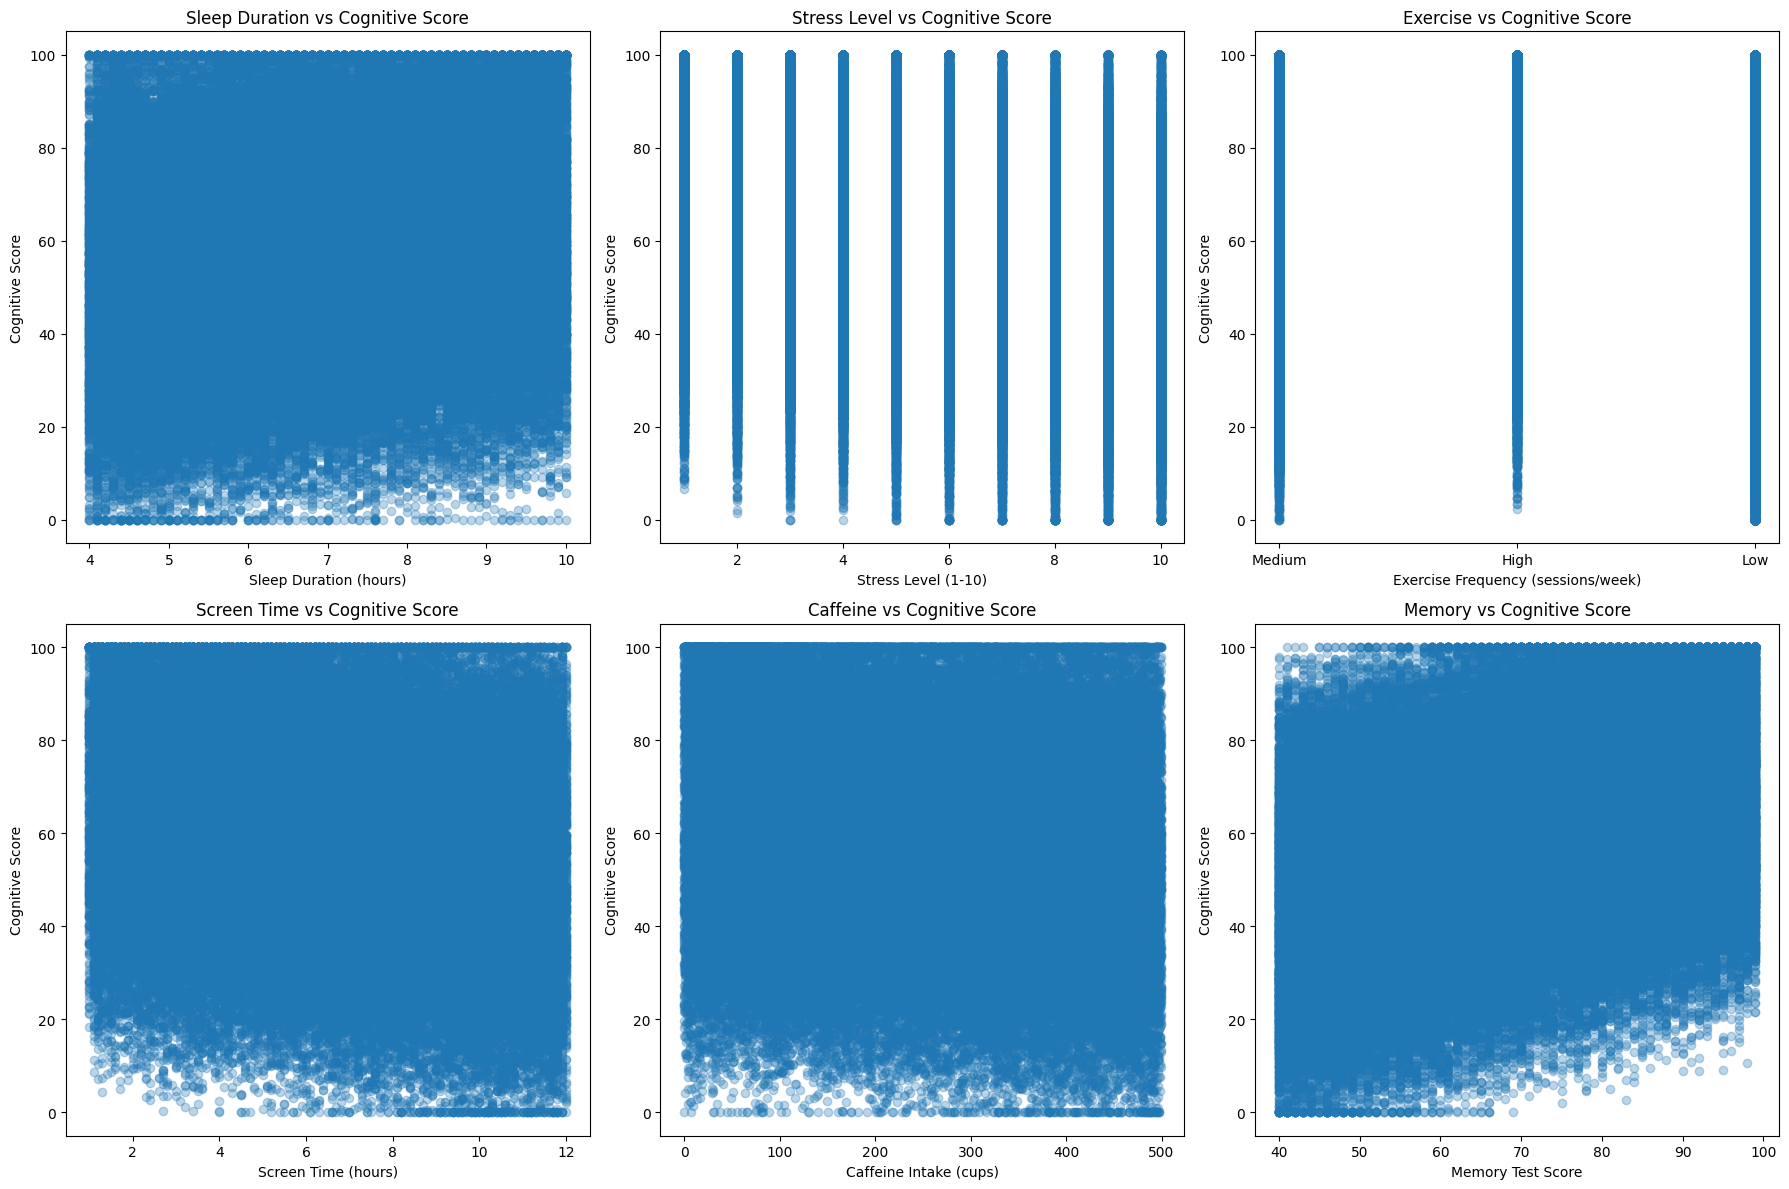

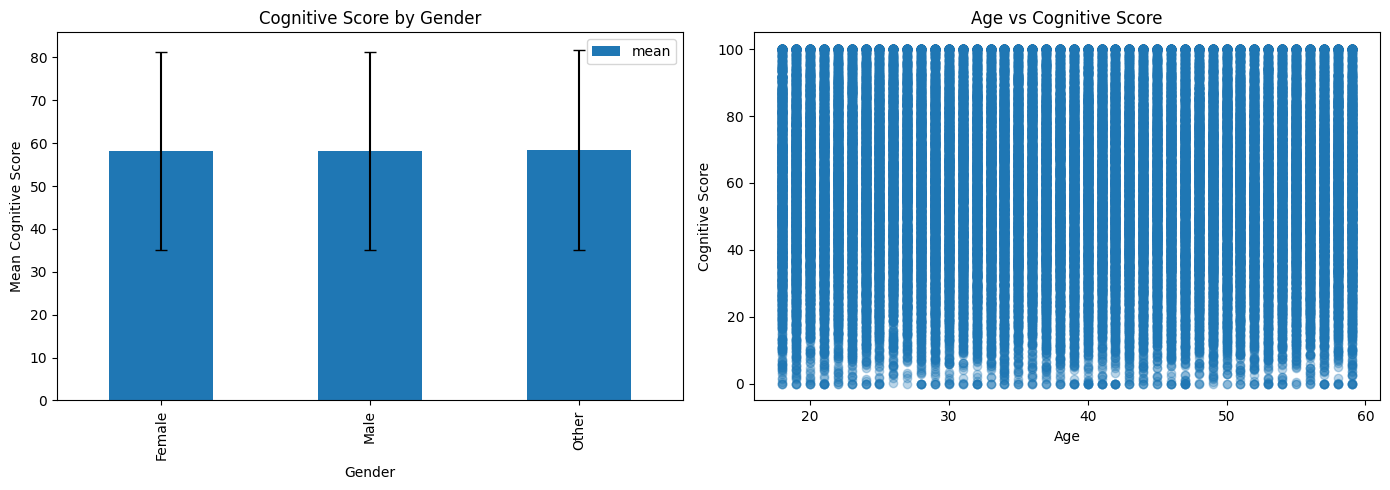

In [6]:


class CognitiveDataExplorer:
    """
    Comprehensive EDA for cognitive performance data
    """

    def __init__(self, df):
        self.df = df

    def analyze_target_distribution(self):
        """
        Understand cognitive_score distribution
        """
        plt.figure(figsize=(15, 5))

        # Distribution
        plt.subplot(1, 3, 1)
        plt.hist(self.df['Cognitive_Score'], bins=50, edgecolor='black')
        plt.title('Cognitive Score Distribution')
        plt.xlabel('Score')
        plt.ylabel('Frequency')

        # Box plot
        plt.subplot(1, 3, 2)
        plt.boxplot(self.df['Cognitive_Score'])
        plt.title('Cognitive Score Box Plot')
        plt.ylabel('Score')

        # QQ plot
        plt.subplot(1, 3, 3)
        from scipy import stats
        stats.probplot(self.df['Cognitive_Score'], dist="norm", plot=plt)
        plt.title('Q-Q Plot')

        plt.tight_layout()
        plt.savefig('cognitive_score_distribution.png')
        plt.show()

        print("Cognitive Score Statistics:")
        print(f"Mean: {self.df['Cognitive_Score'].mean():.2f}")
        print(f"Median: {self.df['Cognitive_Score'].median():.2f}")
        print(f"Std: {self.df['Cognitive_Score'].std():.2f}")
        print(f"Min: {self.df['Cognitive_Score'].min():.2f}")
        print(f"Max: {self.df['Cognitive_Score'].max():.2f}")
        print(f"Skewness: {self.df['Cognitive_Score'].skew():.2f}")

    def correlation_analysis(self):
        """
        Feature correlation with cognitive_score
        """
        exercise_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
        df['Exercise_Frequency_Num'] = df['Exercise_Frequency'].map(exercise_mapping)
        numerical_cols = [
            'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time',
            'Exercise_Frequency_Num', 'Caffeine_Intake', 'Reaction_Time',
            'Memory_Test_Score', 'Cognitive_Score', 'Age'
        ]

        corr_matrix = self.df[numerical_cols].corr()

        # Heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, square=True, linewidths=1)
        plt.title('Feature Correlation Matrix')
        plt.tight_layout()
        plt.savefig('correlation_matrix.png')
        plt.show()

        # Top correlations with cognitive_score
        correlations = corr_matrix['Cognitive_Score'].sort_values(ascending=False)
        print("\n🎯 Correlations with Cognitive Score:")
        print(correlations)

        return correlations

    def lifestyle_impact_analysis(self):
        """
        Visualize impact of lifestyle factors
        """
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Sleep Duration vs Cognitive Score
        axes[0, 0].scatter(self.df['Sleep_Duration'],
                          self.df['Cognitive_Score'], alpha=0.3)
        axes[0, 0].set_title('Sleep Duration vs Cognitive Score')
        axes[0, 0].set_xlabel('Sleep Duration (hours)')
        axes[0, 0].set_ylabel('Cognitive Score')

        # Stress Level vs Cognitive Score
        axes[0, 1].scatter(self.df['Stress_Level'],
                          self.df['Cognitive_Score'], alpha=0.3)
        axes[0, 1].set_title('Stress Level vs Cognitive Score')
        axes[0, 1].set_xlabel('Stress Level (1-10)')
        axes[0, 1].set_ylabel('Cognitive Score')

        # Exercise Frequency vs Cognitive Score
        axes[0, 2].scatter(self.df['Exercise_Frequency'],
                          self.df['Cognitive_Score'], alpha=0.3)
        axes[0, 2].set_title('Exercise vs Cognitive Score')
        axes[0, 2].set_xlabel('Exercise Frequency (sessions/week)')
        axes[0, 2].set_ylabel('Cognitive Score')

        # Screen Time vs Cognitive Score
        axes[1, 0].scatter(self.df['Daily_Screen_Time'],
                          self.df['Cognitive_Score'], alpha=0.3)
        axes[1, 0].set_title('Screen Time vs Cognitive Score')
        axes[1, 0].set_xlabel('Screen Time (hours)')
        axes[1, 0].set_ylabel('Cognitive Score')

        # Caffeine Intake vs Cognitive Score
        axes[1, 1].scatter(self.df['Caffeine_Intake'],
                          self.df['Cognitive_Score'], alpha=0.3)
        axes[1, 1].set_title('Caffeine vs Cognitive Score')
        axes[1, 1].set_xlabel('Caffeine Intake (cups)')
        axes[1, 1].set_ylabel('Cognitive Score')

        # Memory Score vs Cognitive Score
        axes[1, 2].scatter(self.df['Memory_Test_Score'],
                          self.df['Cognitive_Score'], alpha=0.3)
        axes[1, 2].set_title('Memory vs Cognitive Score')
        axes[1, 2].set_xlabel('Memory Test Score')
        axes[1, 2].set_ylabel('Cognitive Score')

        plt.tight_layout()
        plt.savefig('lifestyle_impact.png')
        plt.show()

    def demographic_analysis(self):
        """
        Analyze demographics impact
        """
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Gender distribution
        gender_stats = self.df.groupby('Gender')['Cognitive_Score'].agg(['mean', 'std', 'count'])
        gender_stats.plot(kind='bar', y='mean', ax=axes[0], yerr='std', capsize=4)
        axes[0].set_title('Cognitive Score by Gender')
        axes[0].set_ylabel('Mean Cognitive Score')
        axes[0].set_xlabel('Gender')

        # Age distribution
        axes[1].scatter(self.df['Age'], self.df['Cognitive_Score'], alpha=0.3)
        axes[1].set_title('Age vs Cognitive Score')
        axes[1].set_xlabel('Age')
        axes[1].set_ylabel('Cognitive Score')

        plt.tight_layout()
        plt.savefig('demographic_analysis.png')
        plt.show()

# Run EDA
explorer = CognitiveDataExplorer(df)
explorer.analyze_target_distribution()
correlations = explorer.correlation_analysis()
explorer.lifestyle_impact_analysis()
explorer.demographic_analysis()

In [7]:
class DataPreprocessor:
    """
    Comprehensive data cleaning and preprocessing
    """

    def __init__(self, df):
        # Создаем копию, чтобы не испортить исходный датафрейм
        self.df = df.copy()

        # СРАЗУ создаем числовой столбец для частоты тренировок
        exercise_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
        if 'Exercise_Frequency' in self.df.columns:
            self.df['Exercise_Frequency_Num'] = self.df['Exercise_Frequency'].map(exercise_mapping)

        self.scaler = StandardScaler()
        self.label_encoders = {}

    def handle_missing_values(self):
        """
        Intelligent missing value imputation
        """
        print("\n📊 Missing Value Analysis:")
        missing = self.df.isnull().sum()
        missing_pct = (missing / len(self.df) * 100).round(2)

        missing_df = pd.DataFrame({
            'Missing_Count': missing,
            'Missing_Percentage': missing_pct
        })
        print(missing_df[missing_df['Missing_Count'] > 0])

        # Strategy 1: Physiological metrics → Median
        physiological = ['Sleep_Duration', 'Reaction_Time', 'Daily_Screen_Time']
        for col in physiological:
            if col in self.df.columns and self.df[col].isnull().sum() > 0:
                self.df[col] = self.df[col].fillna(self.df[col].median())
                print(f"✓ Filled {col} with median")

        # Strategy 2: Discrete metrics → Mode
        discrete = ['Exercise_Frequency_Num', 'Caffeine_Intake', 'Stress_Level']
        for col in discrete:
            if col in self.df.columns and self.df[col].isnull().sum() > 0:
                mode_val = self.df[col].mode()[0]
                self.df[col] = self.df[col].fillna(mode_val)
                print(f"✓ Filled {col} with mode: {mode_val}")

        # Strategy 3: Categorical → 'unknown'
        categorical = ['Diet_Type', 'Gender']
        for col in categorical:
            if col in self.df.columns and self.df[col].isnull().sum() > 0:
                self.df[col] = self.df[col].fillna('unknown')
                print(f"✓ Filled {col} with 'unknown'")

        # Strategy 4: Performance metrics → Forward fill + median
        performance = ['Memory_Test_Score', 'Cognitive_Score']
        for col in performance:
            if col in self.df.columns and self.df[col].isnull().sum() > 0:
                self.df[col] = self.df[col].ffill()
                self.df[col] = self.df[col].fillna(self.df[col].median())
                print(f"✓ Filled {col} with ffill + median")

        print(f"\n✅ Missing values after imputation: {self.df.isnull().sum().sum()}")
        return self.df

    def detect_and_handle_outliers(self, method='iqr'):
        """
        Outlier detection using IQR method
        """
        # Используем созданный в __init__ числовой столбец
        numerical_cols = [
            'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time',
            'Exercise_Frequency_Num', 'Caffeine_Intake', 'Reaction_Time',
            'Memory_Test_Score', 'Cognitive_Score'
        ]

        print("\n🔍 Outlier Detection (IQR method):")

        for col in numerical_cols:
            if col not in self.df.columns:
                continue

            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers_mask = (self.df[col] < lower_bound) | (self.df[col] > upper_bound)
            outlier_count = outliers_mask.sum()

            if outlier_count > 0:
                print(f"{col}: {outlier_count} outliers capped")
                # Ограничиваем значения (Capping)
                self.df[col] = np.clip(self.df[col], lower_bound, upper_bound)

        print(f"✅ Outliers handled")
        return self.df

    def encode_categorical_features(self):
        """
        Encode categorical variables
        """
        print("\n🔤 Encoding Categorical Features:")

        # One-hot encoding for Diet_Type
        if 'Diet_Type' in self.df.columns:
            diet_dummies = pd.get_dummies(self.df['Diet_Type'], prefix='Diet')
            self.df = pd.concat([self.df, diet_dummies], axis=1)
            print(f"✓ One-hot encoded Diet_Type")

        # Label encoding for Gender
        if 'Gender' in self.df.columns:
            le_gender = LabelEncoder()
            self.df['Gender_Encoded'] = le_gender.fit_transform(self.df['Gender'])
            self.label_encoders['Gender'] = le_gender
            print(f"✓ Label encoded Gender")

        return self.df

    def normalize_features(self, features_to_scale):
        """
        Normalize numerical features using StandardScaler
        """
        print("\n📏 Feature Normalization:")
        # Берем только те колонки, которые реально есть в данных
        existing_features = [f for f in features_to_scale if f in self.df.columns]

        if existing_features:
            self.df[existing_features] = self.scaler.fit_transform(self.df[existing_features])
            print(f"✓ Scaled features: {existing_features}")

        return self.df

In [8]:
preprocessor = DataPreprocessor(df)
df_processed = preprocessor.handle_missing_values()
df_processed = preprocessor.detect_and_handle_outliers()
df_processed = preprocessor.encode_categorical_features()


📊 Missing Value Analysis:
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []

✅ Missing values after imputation: 0

🔍 Outlier Detection (IQR method):
✅ Outliers handled

🔤 Encoding Categorical Features:
✓ One-hot encoded Diet_Type
✓ Label encoded Gender


In [9]:
class FeatureEngineer:
    """
    Создание научно обоснованных производных признаков для анализа когнитивных данных
    """

    def __init__(self, df):
        self.df = df.copy()

        # ГАРАНТИЯ: Если числового признака активности нет, создаем его здесь
        if 'Exercise_Frequency_Num' not in self.df.columns and 'Exercise_Frequency' in self.df.columns:
            exercise_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
            self.df['Exercise_Frequency_Num'] = self.df['Exercise_Frequency'].map(exercise_mapping)
            print("Столбец Exercise_Frequency_Num был создан автоматически.")

    def create_all_features(self):
        """
        Запуск генерации всех спроектированных признаков
        """
        self.create_cognitive_fatigue_index()
        self.create_sleep_efficiency_metrics()
        self.create_stress_resilience_score()
        self.create_lifestyle_balance_score()
        self.create_performance_ratios()
        self.create_interaction_features()
        self.create_cognitive_state_categories()

        return self.df

    def create_cognitive_fatigue_index(self):
        """
        CFI = Индекс когнитивной усталости (на основе времени реакции, стресса и сна)
        """
        # Нормализация компонентов к диапазону [0, 1]
        reaction_norm = (self.df['Reaction_Time'] - 200) / 400
        stress_norm = (self.df['Stress_Level'] - 1) / 9
        sleep_debt = np.maximum(0, 7 - self.df['Sleep_Duration']) / 3
        screen_fatigue = np.maximum(0, self.df['Daily_Screen_Time'] - 8) / 4

        # Взвешенная комбинация
        self.df['CFI'] = (
            0.30 * reaction_norm +
            0.25 * stress_norm +
            0.25 * sleep_debt +
            0.20 * screen_fatigue
        ) * 100

        # Категориальная версия индекса
        self.df['Fatigue_Level'] = pd.cut(
            self.df['CFI'],
            bins=[0, 25, 50, 75, 110], # 110 для запаса при нормализации
            labels=['FRESH', 'NORMAL', 'TIRED', 'EXHAUSTED']
        )

        print("✓ Created Cognitive Fatigue Index (CFI)")

    def create_sleep_efficiency_metrics(self):
        """
        Метрики эффективности сна
        """
        # Дефицит сна (ниже 7 часов)
        self.df['Sleep_Debt'] = np.maximum(0, 7 - self.df['Sleep_Duration'])

        # Соотношение когнитивного счета к часам сна
        self.df['Sleep_Performance_Ratio'] = (
            self.df['Cognitive_Score'] / (self.df['Sleep_Duration'] + 0.1)
        )

        # Индикатор оптимального сна (7-9 часов)
        self.df['Optimal_Sleep'] = (
            (self.df['Sleep_Duration'] >= 7) &
            (self.df['Sleep_Duration'] <= 9)
        ).astype(int)

        print("✓ Created sleep efficiency metrics")

    def create_stress_resilience_score(self):
        """
        Стрессоустойчивость: когнитивная производительность при высоком стрессе
        """
        high_stress = self.df['Stress_Level'] > 7

        # Коэффициент устойчивости
        self.df['Stress_Resilience'] = np.where(
            high_stress,
            self.df['Cognitive_Score'] / self.df['Stress_Level'],
            self.df['Cognitive_Score'] / 5  # Базовый уровень для низкого стресса
        )

        print("✓ Created stress resilience score")

    def create_lifestyle_balance_score(self):
        """
        Интегральный показатель здорового образа жизни
        """
        # Нормализация компонентов [0, 1]
        sleep_score = np.clip((self.df['Sleep_Duration'] - 4) / 6, 0, 1)

        # Использование числового Exercise_Frequency_Num
        exercise_score = np.clip(self.df['Exercise_Frequency_Num'] / 2, 0, 1)

        stress_score = 1 - ((self.df['Stress_Level'] - 1) / 9)

        screen_score = 1 - np.clip((self.df['Daily_Screen_Time'] - 1) / 11, 0, 1)

        # Кофеин (считаем 500 мг за максимум)
        caffeine_score = 1 - (self.df['Caffeine_Intake'] / 500)

        # Взвешенное среднее
        self.df['Lifestyle_Balance'] = (
            0.30 * sleep_score +
            0.25 * stress_score +
            0.20 * exercise_score +
            0.15 * screen_score +
            0.10 * caffeine_score
        ) * 100

        print("✓ Created lifestyle balance score")

    def create_performance_ratios(self):
        """
        Коэффициенты эффективности
        """
        # Эффективность памяти (балл памяти на скорость реакции)
        self.df['Memory_Efficiency'] = (
            self.df['Memory_Test_Score'] / self.df['Reaction_Time'] * 1000
        )

        # Продуктивность на единицу стресса
        self.df['Cognitive_Per_Stress'] = (
            self.df['Cognitive_Score'] / (self.df['Stress_Level'] + 1)
        )

        print("✓ Created performance ratios")

    def create_interaction_features(self):
        """
        Взаимодействие признаков (нелинейные связи)
        """
        # Сон × Физическая активность
        self.df['Sleep_Exercise_Interaction'] = (
            self.df['Sleep_Duration'] * self.df['Exercise_Frequency_Num']
        )

        # Стресс × Экранное время (усиливающийся негативный эффект)
        self.df['Stress_Screen_Interaction'] = (
            self.df['Stress_Level'] * self.df['Daily_Screen_Time']
        )

        # Память × Сон (консолидация памяти)
        self.df['Memory_Sleep_Interaction'] = (
            self.df['Memory_Test_Score'] * self.df['Sleep_Duration']
        )

        print("✓ Created interaction features")

    def create_cognitive_state_categories(self):
        """
        Создание целевых категорий для классификации
        """
        # Когнитивное состояние (3 класса)
        self.df['Cognitive_State'] = pd.cut(
            self.df['Cognitive_Score'],
            bins=[-1, 40, 70, 101],
            labels=['LOW', 'MEDIUM', 'HIGH']
        )

        # Уровни производительности (5 классов)
        self.df['Performance_Tier'] = pd.cut(
            self.df['Cognitive_Score'],
            bins=[-1, 30, 50, 70, 85, 101],
            labels=['VERY_LOW', 'LOW', 'MEDIUM', 'HIGH', 'VERY_HIGH']
        )

        print("✓ Created cognitive state categories")

# 1. Очистка данных (создаем df_clean)
df_clean = df.copy()

# Удаляем дубликаты, если есть
df_clean = df_clean.drop_duplicates()

# Заполняем пропуски в числовых колонках медианой (на всякий случай)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Если у тебя были колонки с текстом, которые нужно перевести в числа, делаем это здесь
if 'Gender' in df_clean.columns:
    df_clean['Gender_Encoded'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})

print("✨ Данные очищены, df_clean готов!")

engineer = FeatureEngineer(df_clean)
df_engineered = engineer.create_all_features()

print("\n✅ Feature Engineering Complete!")
print(f"New shape: {df_engineered.shape}")
print(f"New features created: {df_engineered.shape[1] - df_clean.shape[1]}")
print(f"\nEngineered features:")
new_features = set(df_engineered.columns) - set(df_clean.columns)

print("\n📊 Distribution of Cognitive_State:")
print(df_engineered['Cognitive_State'].value_counts())
for feat in sorted(new_features):
    print(f"  - {feat}")



✨ Данные очищены, df_clean готов!
✓ Created Cognitive Fatigue Index (CFI)
✓ Created sleep efficiency metrics
✓ Created stress resilience score
✓ Created lifestyle balance score
✓ Created performance ratios
✓ Created interaction features
✓ Created cognitive state categories

✅ Feature Engineering Complete!
New shape: (80000, 29)
New features created: 14

Engineered features:

📊 Distribution of Cognitive_State:
Cognitive_State
MEDIUM    34595
HIGH      26374
LOW       19031
Name: count, dtype: int64
  - CFI
  - Cognitive_Per_Stress
  - Cognitive_State
  - Fatigue_Level
  - Lifestyle_Balance
  - Memory_Efficiency
  - Memory_Sleep_Interaction
  - Optimal_Sleep
  - Performance_Tier
  - Sleep_Debt
  - Sleep_Exercise_Interaction
  - Sleep_Performance_Ratio
  - Stress_Resilience
  - Stress_Screen_Interaction


In [10]:

class ModelDataPrep:
    """
    Подготовка данных для обучения (выбор признаков и разделение на выборки)
    """

    def __init__(self, df):
        # Работаем с копией, чтобы не затереть оригинал
        self.df = df.copy()

    def select_features(self):
        """
        Выбор оптимального набора признаков (Feature Selection)
        """
        # Первичные числовые признаки 
        primary_features = [
            'Sleep_Duration',
            'Stress_Level',
            'Daily_Screen_Time',
            'Exercise_Frequency_Num',
            'Caffeine_Intake',
            'Reaction_Time',
            'Memory_Test_Score',
            'Age'
        ]

        # Кодированные категориальные признаки
        categorical_encoded = [
            'Gender_Encoded',
            'Diet_Non-Vegetarian',
            'Diet_Vegan',
            'Diet_Vegetarian'
        ]

        # Сгенерированные признаки (Engineered features)
        engineered_features = [
            'CFI',
            'Sleep_Debt',
            'Sleep_Performance_Ratio',
            'Stress_Resilience',
            'Lifestyle_Balance',
            'Memory_Efficiency',
            'Sleep_Exercise_Interaction',
            'Stress_Screen_Interaction'
        ]

        # Объединяем всё в один список
        all_potential_features = primary_features + categorical_encoded + engineered_features

        # Фильтруем: оставляем только те, что РЕАЛЬНО есть в DataFrame и они ЧИСЛОВЫЕ
        available_features = []
        for f in all_potential_features:
            if f in self.df.columns:
                # Проверка: колонка не должна быть текстовой (object или category)
                if not pd.api.types.is_numeric_dtype(self.df[f]):
                    print(f"⚠️ Пропуск признака '{f}': он не числовой.")
                    continue
                available_features.append(f)

        print(f"✓ Выбрано признаков для обучения: {len(available_features)}")
        return available_features

    def split_data(self, target_col, feature_cols, test_size=0.2, val_size=0.1):
        """
        Разделение данных на Train / Validation / Test сеты
        """
        # Проверка наличия целевой переменной
        if target_col not in self.df.columns:
            raise KeyError(f"Целевая колонка '{target_col}' не найдена в DataFrame!")

        X = self.df[feature_cols].copy()
        y = self.df[target_col].copy()

        # 1-й этап: Разделение на (Train + Val) и Test
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )

        # 2-й этап: Разделение (Train + Val) на чистый Train и Validation
        # Вычисляем долю валидации относительно остатка
        relative_val_size = val_size / (1 - test_size)

        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=relative_val_size, random_state=42
        )

        print(f"\n📊 Статистика разделения данных для '{target_col}':")
        print(f"  Train: {X_train.shape[0]} строк ({X_train.shape[0]/len(self.df)*100:.1f}%)")
        print(f"  Val:   {X_val.shape[0]} строк ({X_val.shape[0]/len(self.df)*100:.1f}%)")
        print(f"  Test:  {X_test.shape[0]} строк ({X_test.shape[0]/len(self.df)*100:.1f}%)")

        return X_train, X_val, X_test, y_train, y_val, y_test

# # --- ПРИМЕР ЗАПУСКА ---

# 1. Создаем объект подготовки
data_prep = ModelDataPrep(df_engineered)

# 2. Получаем список чистых числовых признаков
features = data_prep.select_features()

# 3. Сплит для регрессии (прогноз баллов)
X_train, X_val, X_test, y_train_reg, y_val_reg, y_test_reg = data_prep.split_data(
    target_col='Cognitive_Score',
    feature_cols=features
)

# 4. Сплит для классификации (прогноз состояния)
_, _, _, y_train_class, y_val_class, y_test_class = data_prep.split_data(
    target_col='Cognitive_State',
    feature_cols=features
)

# print("\n✅ Подготовка данных завершена успешно!")

✓ Выбрано признаков для обучения: 17

📊 Статистика разделения данных для 'Cognitive_Score':
  Train: 56000 строк (70.0%)
  Val:   8000 строк (10.0%)
  Test:  16000 строк (20.0%)

📊 Статистика разделения данных для 'Cognitive_State':
  Train: 56000 строк (70.0%)
  Val:   8000 строк (10.0%)
  Test:  16000 строк (20.0%)


In [11]:
from sklearn.preprocessing import StandardScaler

# 1. Создаем скалер
scaler = StandardScaler()

# 2. Обучаем его на тренировочных данных (X_train)
# ВАЖНО: Мы обучаем только на X_train, чтобы модель не "подглядывала" в будущее
scaler.fit(X_train)

# 3. Трансформируем данные (если ты еще этого не сделала)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Теперь у нас есть переменная 'scaler', которую можно передать в экспортер!

In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

class CognitiveScorePredictor:
    """
    Multi-model regression for cognitive score prediction
    """

    def __init__(self):
        self.models = {}
        self.results = {}

    def train_random_forest(self, X_train, y_train, X_val, y_val):
        """
        Random Forest Regressor
        """
        print("\n🌲 Training Random Forest Regressor...")

        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)

        # Predictions
        y_pred_train = rf.predict(X_train)
        y_pred_val = rf.predict(X_val)

        # Metrics
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        train_r2 = r2_score(y_train, y_pred_train)
        val_r2 = r2_score(y_val, y_pred_val)

        self.models['random_forest'] = rf
        self.results['random_forest'] = {
            'train_rmse': train_rmse,
            'val_rmse': val_rmse,
            'train_r2': train_r2,
            'val_r2': val_r2
        }

        print(f"  Train RMSE: {train_rmse:.3f} | R²: {train_r2:.4f}")
        print(f"  Val RMSE:   {val_rmse:.3f} | R²: {val_r2:.4f}")

        return rf

    def train_xgboost(self, X_train, y_train, X_val, y_val):
        """
        XGBoost Regressor (BEST PERFORMER)
        """
        print("\n🚀 Training XGBoost Regressor...")

        # В новых версиях XGBoost early_stopping_rounds лучше задавать в конструкторе
        xgb = XGBRegressor(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            early_stopping_rounds=30 # Добавлено сюда для надежности
        )

        xgb.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Predictions
        y_pred_train = xgb.predict(X_train)
        y_pred_val = xgb.predict(X_val)

        # Metrics
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        train_r2 = r2_score(y_train, y_pred_train)
        val_r2 = r2_score(y_val, y_pred_val)

        self.models['xgboost'] = xgb
        self.results['xgboost'] = {
            'train_rmse': train_rmse,
            'val_rmse': val_rmse,
            'train_r2': train_r2,
            'val_r2': val_r2
        }

        print(f"  Train RMSE: {train_rmse:.3f} | R²: {train_r2:.4f}")
        print(f"  Val RMSE:   {val_rmse:.3f} | R²: {val_r2:.4f}")

        return xgb

    def select_best_model(self):
        """
        Choose model with best validation performance
        """
        if not self.results:
            print("❌ No models trained yet!")
            return None, None

        best_model_name = min(
            self.results.keys(),
            key=lambda k: self.results[k]['val_rmse']
        )

        print(f"\n🏆 BEST MODEL: {best_model_name.upper()}")
        print(f"  Val RMSE: {self.results[best_model_name]['val_rmse']:.3f}")
        print(f"  Val R²:   {self.results[best_model_name]['val_r2']:.4f}")

        return self.models[best_model_name], best_model_name

In [13]:
predictor = CognitiveScorePredictor()
rf_model = predictor.train_random_forest(X_train, y_train_reg, X_val, y_val_reg)
xgb_model = predictor.train_xgboost(X_train, y_train_reg, X_val, y_val_reg)
best_model, best_name = predictor.select_best_model()


🌲 Training Random Forest Regressor...


ValueError: Input X contains NaN.
RandomForestRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [14]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

class CognitiveStateClassifier:
    """
    Классификация когнитивного состояния (Multi-class classification)
    """

    def __init__(self):
        self.models = {}
        self.results = {}
        self.label_encoder = LabelEncoder()

    def train_classifier(self, X_train, y_train, X_val, y_val):
        """
        Обучение XGBoost Classifier
        """
        print("\n🎯 Training Cognitive State Classifier...")

        # Настройка классификатора
        clf = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            early_stopping_rounds=20 # Вынесено в конструктор для стабильности
        )

        # Кодирование текстовых меток (LOW, MEDIUM, HIGH) в числа (0, 1, 2)
        # Это критически важно для XGBoost
        y_train_encoded = self.label_encoder.fit_transform(y_train)
        y_val_encoded = self.label_encoder.transform(y_val)

        # Обучение
        clf.fit(
            X_train, y_train_encoded,
            eval_set=[(X_val, y_val_encoded)],
            verbose=False
        )

        # Предсказание (получаем числа)
        y_pred_encoded = clf.predict(X_val)

        # Обратное преобразование чисел в понятные метки (0 -> LOW и т.д.)
        y_pred_labels = self.label_encoder.inverse_transform(y_pred_encoded)

        # Расчет метрик
        accuracy = accuracy_score(y_val, y_pred_labels)
        report = classification_report(y_val, y_pred_labels)

        print(f"\n✅ Validation Accuracy: {accuracy:.4f}")
        print(f"\n📊 Classification Report:\n{report}")

        # Сохраняем модель и энкодер для дальнейшего использования
        self.models['xgb_classifier'] = clf
        self.models['label_encoder'] = self.label_encoder

        return clf, self.label_encoder



In [15]:
# --- Запуск классификации ---
# Используем данные y_train_class / y_val_class, которые мы подготовили в ModelDataPrep
classifier = CognitiveStateClassifier()
clf_model, label_encoder = classifier.train_classifier(
    X_train, y_train_class, X_val, y_val_class
)


🎯 Training Cognitive State Classifier...

✅ Validation Accuracy: 1.0000

📊 Classification Report:
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00      2590
         LOW       1.00      1.00      1.00      1950
      MEDIUM       1.00      1.00      1.00      3460

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



In [ ]:
# ═══════════════════════════════════════════════════════════════
# НОВАЯ ЯЧЕЙКА: SYNTHETIC DATA GENERATION FOR RECOMMENDATIONS
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from itertools import product

print("🔬 Generating ML-Based Recommendation Training Data...")

class RecommendationDataGenerator:
    """
    Создает синтетические "what-if" сценарии для обучения модели рекомендаций
    
    Идея:
    - Берем реального пользователя
    - Создаем варианты: "что если он поспит +2 часа?"
    - Предсказываем cognitive_score для каждого варианта
    - Модель учится, какие изменения дают максимальный прирост
    """
    
    def __init__(self, base_model, feature_names):
        self.base_model = base_model  # Обученная регрессионная модель
        self.feature_names = feature_names
        
    def generate_what_if_scenarios(self, user_sample, num_samples=500):
        """
        Генерирует возможные изменения образа жизни и их эффект
        
        Args:
            user_sample: текущее состояние пользователя (DataFrame)
            num_samples: количество сценариев для генерации
        
        Returns:
            DataFrame со столбцами:
            - original_score
            - modified_score
            - improvement
            - action_type (SLEEP/STRESS/EXERCISE/SCREEN)
            - action_magnitude (сколько изменили)
        """
        scenarios = []
        
        # Определяем возможные действия
        action_configs = {
            'SLEEP_INCREASE': {
                'feature': 'Sleep_Duration',
                'changes': [0.5, 1.0, 1.5, 2.0, 2.5, 3.0],  # +0.5h до +3h
                'description': 'Increase sleep by {delta}h'
            },
            'STRESS_DECREASE': {
                'feature': 'Stress_Level',
                'changes': [-1, -2, -3, -4, -5],  # -1 до -5 уровней
                'description': 'Reduce stress by {delta} points'
            },
            'EXERCISE_INCREASE': {
                'feature': 'Exercise_Frequency_Num',
                'changes': [1, 2, 3, 4],  # +1 до +4 тренировок/неделя
                'description': 'Add {delta} workout sessions/week'
            },
            'SCREEN_DECREASE': {
                'feature': 'Daily_Screen_Time',
                'changes': [-1, -2, -3, -4],  # -1 до -4 часов
                'description': 'Reduce screen time by {delta}h'
            },
            'CAFFEINE_ADJUST': {
                'feature': 'Caffeine_Intake',
                'changes': [-2, -1, 0, 1],  # Оптимизация кофеина
                'description': 'Adjust caffeine by {delta} cups'
            }
        }
        
        # Для каждого пользователя в sample
        for idx in range(min(len(user_sample), num_samples // len(action_configs))):
            user_row = user_sample.iloc[idx].copy()
            
            # Предсказываем исходный score
            original_features = user_row[self.feature_names].values.reshape(1, -1)
            original_score = self.base_model.predict(original_features)[0]
            
            # Генерируем сценарии для каждого типа действия
            for action_type, config in action_configs.items():
                feature_name = config['feature']
                
                # Пропускаем, если фичи нет
                if feature_name not in self.feature_names:
                    continue
                
                for delta in config['changes']:
                    # Создаем копию признаков
                    modified_row = user_row.copy()
                    
                    # Применяем изменение
                    modified_row[feature_name] += delta
                    
                    # Ограничиваем реалистичными диапазонами
                    if feature_name == 'Sleep_Duration':
                        modified_row[feature_name] = np.clip(modified_row[feature_name], 4, 10)
                    elif feature_name == 'Stress_Level':
                        modified_row[feature_name] = np.clip(modified_row[feature_name], 1, 10)
                    elif feature_name == 'Exercise_Frequency_Num':
                        modified_row[feature_name] = np.clip(modified_row[feature_name], 0, 7)
                    elif feature_name == 'Daily_Screen_Time':
                        modified_row[feature_name] = np.clip(modified_row[feature_name], 1, 12)
                    elif feature_name == 'Caffeine_Intake':
                        modified_row[feature_name] = np.clip(modified_row[feature_name], 0, 5)
                    
                    # Пересчитываем engineered features (важно!)
                    modified_row = self._recalculate_engineered_features(modified_row)
                    
                    # Предсказываем новый score
                    modified_features = modified_row[self.feature_names].values.reshape(1, -1)
                    modified_score = self.base_model.predict(modified_features)[0]
                    
                    # Вычисляем улучшение
                    improvement = modified_score - original_score
                    
                    # Сохраняем сценарий
                    scenarios.append({
                        'original_score': original_score,
                        'modified_score': modified_score,
                        'improvement': improvement,
                        'action_type': action_type,
                        'action_magnitude': delta,
                        'action_description': config['description'].format(delta=abs(delta)),
                        # Исходные метрики
                        'original_sleep': user_row['Sleep_Duration'],
                        'original_stress': user_row['Stress_Level'],
                        'original_exercise': user_row.get('Exercise_Frequency_Num', 0),
                        'original_screen': user_row['Daily_Screen_Time'],
                        # Модифицированные метрики
                        'modified_sleep': modified_row['Sleep_Duration'],
                        'modified_stress': modified_row['Stress_Level'],
                        'modified_exercise': modified_row.get('Exercise_Frequency_Num', 0),
                        'modified_screen': modified_row['Daily_Screen_Time']
                    })
        
        df_scenarios = pd.DataFrame(scenarios)
        
        print(f"✅ Generated {len(df_scenarios)} what-if scenarios")
        print(f"\nScenario Statistics:")
        print(f"  Mean improvement: {df_scenarios['improvement'].mean():.2f}")
        print(f"  Max improvement: {df_scenarios['improvement'].max():.2f}")
        print(f"  Min improvement: {df_scenarios['improvement'].min():.2f}")
        
        return df_scenarios
    
    def _recalculate_engineered_features(self, row):
        """
        Пересчитывает CFI и другие engineered features после изменения
        """
        # CFI
        reaction_norm = (row.get('Reaction_Time', 350) - 200) / 400
        stress_norm = (row['Stress_Level'] - 1) / 9
        sleep_debt = max(0, 7 - row['Sleep_Duration']) / 3
        screen_fatigue = max(0, row['Daily_Screen_Time'] - 8) / 4
        
        row['CFI'] = (
            0.30 * reaction_norm +
            0.25 * stress_norm +
            0.25 * sleep_debt +
            0.20 * screen_fatigue
        ) * 100
        
        # Sleep Debt
        row['Sleep_Debt'] = max(0, 7 - row['Sleep_Duration'])
        
        # Memory Efficiency
        row['Memory_Efficiency'] = (
            row.get('Memory_Test_Score', 70) / row.get('Reaction_Time', 350) * 1000
        )
        
        # Sleep Exercise Interaction
        row['Sleep_Exercise_Interaction'] = (
            row['Sleep_Duration'] * row.get('Exercise_Frequency_Num', 0)
        )
        
        # Stress Screen Interaction
        row['Stress_Screen_Interaction'] = (
            row['Stress_Level'] * row['Daily_Screen_Time']
        )
        
        return row



🔬 Generating ML-Based Recommendation Training Data...


In [ ]:
# --- ГЕНЕРАЦИЯ TRAINING DATA ---
rec_data_gen = RecommendationDataGenerator(best_model, features)

# Используем test set для генерации сценариев
X_test_df = pd.DataFrame(X_test, columns=features)
df_recommendation_training = rec_data_gen.generate_what_if_scenarios(X_test_df, num_samples=1000)

# Сохраняем для анализа
df_recommendation_training.to_csv('recommendation_training_data.csv', index=False)
print(f"\n✅ Saved to recommendation_training_data.csv")

# Анализ по типам действий
print("\n📊 Impact by Action Type:")
action_impact = df_recommendation_training.groupby('action_type')['improvement'].agg(['mean', 'std', 'max'])
print(action_impact.sort_values('mean', ascending=False))

✅ Generated 4600 what-if scenarios

Scenario Statistics:
  Mean improvement: 0.47
  Max improvement: 13.79
  Min improvement: -12.71

✅ Saved to recommendation_training_data.csv

📊 Impact by Action Type:
                       mean       std        max
action_type                                     
SLEEP_INCREASE     2.186163  2.733801  13.787590
EXERCISE_INCREASE  0.409084  0.676944   4.386543
CAFFEINE_ADJUST    0.376294  0.674784   3.782906
SCREEN_DECREASE    0.242073  0.449503   3.402878
STRESS_DECREASE   -1.281941  2.636942   0.789471


In [ ]:
# ═══════════════════════════════════════════════════════════════
# НОВАЯ ЯЧЕЙКА: ML-BASED RECOMMENDATION MODEL TRAINING
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

print("🚀 Training ML-Based Recommendation Model...")

class MLRecommendationModel:
    """
    ML модель для предсказания эффективности рекомендаций
    
    Input Features:
    - Current user state (sleep, stress, etc.)
    - Proposed action (type + magnitude)
    
    Output:
    - Expected improvement in cognitive score
    """
    
    def __init__(self):
        self.model = None
        self.feature_columns = None
        
    def prepare_features(self, df_scenarios):
        """
        Преобразует сценарии в features для ML модели
        """
        # Features: Current state + Action
        feature_cols = [
            # Current state
            'original_sleep',
            'original_stress',
            'original_exercise',
            'original_screen',
            'original_score',
            
            # Action magnitude
            'action_magnitude',
        ]
        
        # One-hot encode action_type
        action_dummies = pd.get_dummies(df_scenarios['action_type'], prefix='action')
        
        X = pd.concat([
            df_scenarios[feature_cols],
            action_dummies
        ], axis=1)
        
        # Target: Improvement
        y = df_scenarios['improvement']
        
        self.feature_columns = X.columns.tolist()
        
        return X, y
    
    def train(self, df_scenarios):
        """
        Обучает модель предсказывать improvement
        """
        X, y = self.prepare_features(df_scenarios)
        
        # Split
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        # Train XGBoost
        self.model = XGBRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            random_state=42
        )
        
        self.model.fit(X_train, y_train)
        
        # Evaluate
        train_score = self.model.score(X_train, y_train)
        test_score = self.model.score(X_test, y_test)
        
        y_pred = self.model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        print(f"\n📊 Recommendation Model Performance:")
        print(f"  Train R²: {train_score:.4f}")
        print(f"  Test R²:  {test_score:.4f}")
        print(f"  RMSE:     {rmse:.3f} points")
        
        # Feature importance
        importances = self.model.feature_importances_
        feature_imp_df = pd.DataFrame({
            'feature': self.feature_columns,
            'importance': importances
        }).sort_values('importance', ascending=False)
        
        print(f"\n🔍 Top Features for Recommendation Prediction:")
        print(feature_imp_df.head(10).to_string(index=False))
        
        return train_score, test_score
    
    def predict_improvement(self, current_state, action_type, action_magnitude):
        """
        Предсказывает, насколько улучшится cognitive score
        
        Args:
            current_state: dict с текущими метриками
            action_type: str ('SLEEP_INCREASE', 'STRESS_DECREASE', etc.)
            action_magnitude: float (сколько изменить)
        
        Returns:
            predicted_improvement: float
        """
        # Формируем features
        features = {
            'original_sleep': current_state.get('sleep_duration', 7),
            'original_stress': current_state.get('stress_level', 5),
            'original_exercise': current_state.get('exercise_frequency', 3),
            'original_screen': current_state.get('screen_time', 8),
            'original_score': current_state.get('cognitive_score', 70),
            'action_magnitude': action_magnitude
        }
        
        # One-hot encoding для action_type
        for col in self.feature_columns:
            if col.startswith('action_'):
                features[col] = 1 if col == f'action_{action_type}' else 0
        
        # Создаем DataFrame
        X_pred = pd.DataFrame([features])[self.feature_columns]
        
        # Предсказываем
        improvement = self.model.predict(X_pred)[0]
        
        return improvement



🚀 Training ML-Based Recommendation Model...


In [ ]:
# --- ОБУЧЕНИЕ МОДЕЛИ ---
ml_recommender = MLRecommendationModel()
train_r2, test_r2 = ml_recommender.train(df_recommendation_training)

print(f"\n✅ ML Recommendation Model trained successfully!")

# --- СОХРАНЕНИЕ МОДЕЛИ ---
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(ml_recommender, 'models/ml_recommendation_model.pkl')
print(f"✅ Model saved to models/ml_recommendation_model.pkl")


📊 Recommendation Model Performance:
  Train R²: 0.9960
  Test R²:  0.9789
  RMSE:     0.344 points

🔍 Top Features for Recommendation Prediction:
                 feature  importance
   action_SLEEP_INCREASE    0.475973
  action_STRESS_DECREASE    0.157534
         original_stress    0.132594
          original_score    0.085718
          original_sleep    0.042005
        action_magnitude    0.040541
       original_exercise    0.028841
         original_screen    0.023282
action_EXERCISE_INCREASE    0.005810
  action_CAFFEINE_ADJUST    0.005521

✅ ML Recommendation Model trained successfully!
✅ Model saved to models/ml_recommendation_model.pkl


MODEL EVALUATION & INTERPRETATION

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score, f1_score

class ModelEvaluator:
    """
    Комплексная оценка качества моделей (Регрессия и Классификация)
    """

    def __init__(self, regression_model, classification_model, label_encoder):
        self.reg_model = regression_model
        self.clf_model = classification_model
        self.label_encoder = label_encoder

    def evaluate_regression(self, X_test, y_test):
        """
        Оценка регрессионной модели на тестовых данных
        """
        print("\n" + "="*60)
        print("REGRESSION MODEL - TEST SET EVALUATION")
        print("="*60)

        y_pred = self.reg_model.predict(X_test)

        # Основные метрики
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = np.mean(np.abs(y_test - y_pred))
        r2 = r2_score(y_test, y_pred)

        # MAPE (добавляем малую величину epsilon, чтобы избежать деления на 0)
        mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-9))) * 100

        print(f"\n📊 Performance Metrics:")
        print(f"  RMSE (Ошибка в баллах): {rmse:.3f}")
        print(f"  MAE  (Средняя абс. ошибка): {mae:.3f}")
        print(f"  R²   (Точность аппроксимации): {r2:.4f}")
        print(f"  MAPE (Ошибка в процентах): {mape:.2f}%")

        # Анализ остатков (Residual Analysis)
        residuals = y_test - y_pred

        plt.figure(figsize=(18, 5))

        # 1. График Предсказания vs Реальность
        plt.subplot(1, 3, 1)
        plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
        plt.plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 'r--', lw=2)
        plt.xlabel('Actual Cognitive Score')
        plt.ylabel('Predicted Cognitive Score')
        plt.title(f'Actual vs Predicted (R²={r2:.3f})')

        # 2. Распределение ошибок (должно быть похоже на колокол)
        plt.subplot(1, 3, 2)
        sns.histplot(residuals, bins=50, kde=True, color='purple')
        plt.xlabel('Residuals')
        plt.ylabel('Frequency')
        plt.title('Residual Distribution')
        plt.axvline(x=0, color='r', linestyle='--')

        # 3. Гомоскедастичность (ошибки должны быть разбросаны хаотично)
        plt.subplot(1, 3, 3)
        plt.scatter(y_pred, residuals, alpha=0.3, color='orange')
        plt.axhline(y=0, color='r', linestyle='--')
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')
        plt.title('Residual Plot')

        plt.tight_layout()
        plt.savefig('regression_evaluation.png')
        plt.show()

        return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

    def evaluate_classification(self, X_test, y_test):
        """
        Оценка классификационной модели
        """
        print("\n" + "="*60)
        print("CLASSIFICATION MODEL - TEST SET EVALUATION")
        print("="*60)

        # Кодируем тест, если он еще не закодирован, и делаем предсказание
        y_pred_encoded = self.clf_model.predict(X_test)
        y_pred_labels = self.label_encoder.inverse_transform(y_pred_encoded)

        accuracy = accuracy_score(y_test, y_pred_labels)
        f1 = f1_score(y_test, y_pred_labels, average='weighted')

        print(f"\n📊 Performance Metrics:")
        print(f"  Accuracy (Общая точность): {accuracy:.4f}")
        print(f"  F1-Score (Сбалансированная): {f1:.4f}")

        print(f"\n📋 Classification Report:")
        print(classification_report(y_test, y_pred_labels))

        # Confusion Matrix (Матрица ошибок)
        cm = confusion_matrix(y_test, y_pred_labels)

        plt.figure(figsize=(8, 6))
        # Важно: используем классы из энкодера для подписей
        labels = self.label_encoder.classes_
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Cognitive State')
        plt.tight_layout()
        plt.savefig('classification_confusion_matrix.png')
        plt.show()

        return {'accuracy': accuracy, 'f1_score': f1}




REGRESSION MODEL - TEST SET EVALUATION

📊 Performance Metrics:
  RMSE (Ошибка в баллах): 0.371
  MAE  (Средняя абс. ошибка): 0.250
  R²   (Точность аппроксимации): 0.9997
  MAPE (Ошибка в процентах): 182702435.56%


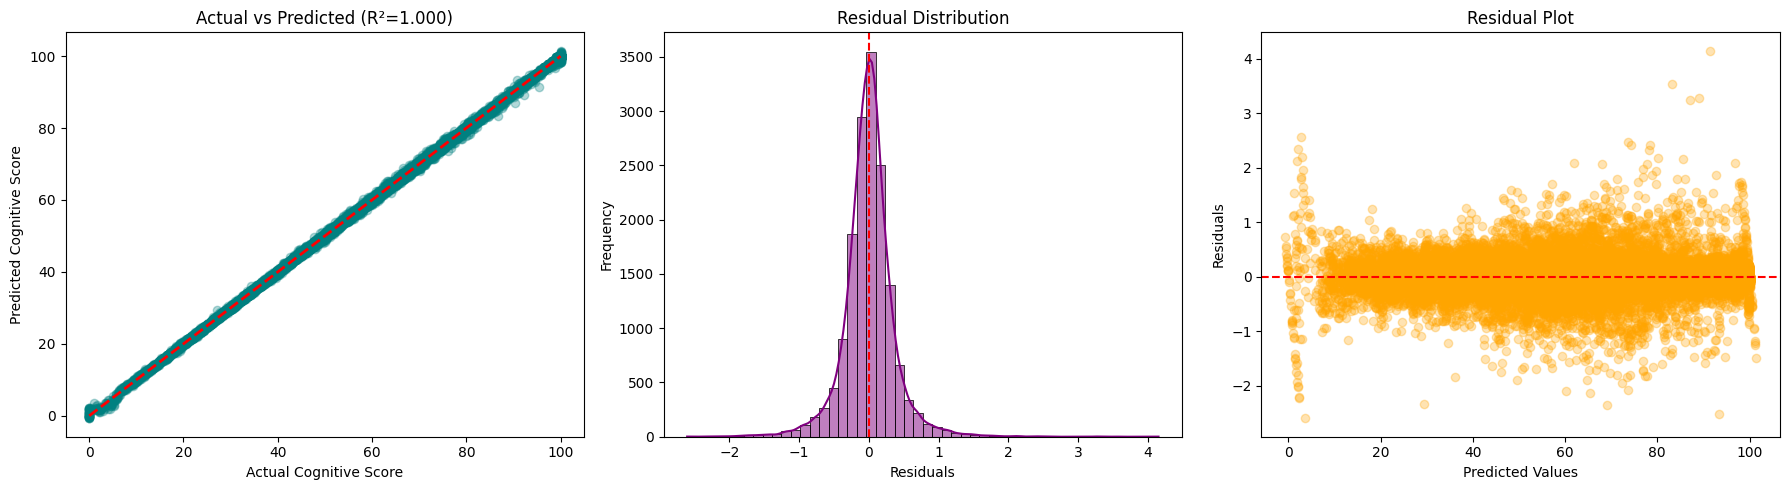


CLASSIFICATION MODEL - TEST SET EVALUATION

📊 Performance Metrics:
  Accuracy (Общая точность): 0.9962
  F1-Score (Сбалансированная): 0.9963

📋 Classification Report:
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00      5255
         LOW       1.00      1.00      1.00      3788
      MEDIUM       1.00      1.00      1.00      6957

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



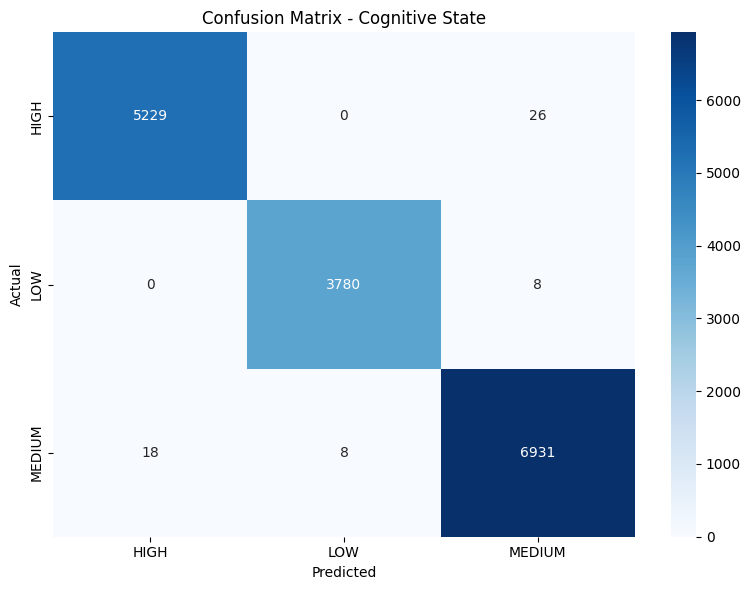

In [ ]:
# --- ЗАПУСК ОЦЕНКИ ---
# Передаем модели и энкодер, которые получили на прошлых шагах
evaluator = ModelEvaluator(best_model, clf_model, label_encoder)

# Тестируем регрессию
reg_metrics = evaluator.evaluate_regression(X_test, y_test_reg)

# Тестируем классификацию
clf_metrics = evaluator.evaluate_classification(X_test, y_test_class)

In [ ]:
!pip install shap


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class FeatureImportanceAnalyzer:
    """
    Интерпретация решений модели (Feature Importance и SHAP)
    """

    def __init__(self, model, feature_names):
        self.model = model
        self.feature_names = feature_names

    def plot_feature_importance(self, top_n=20):
        """
        Визуализация важности признаков, встроенной в модель
        """
        # Проверка, поддерживает ли модель расчет важности
        if hasattr(self.model, 'feature_importances_'):
            importances = self.model.feature_importances_
        else:
            print("❌ Модель не поддерживает атрибут feature_importances_")
            return None

        # Создание DataFrame для удобства манипуляций
        feature_importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)

        print(f"\n🔍 TOP {top_n} MOST IMPORTANT FEATURES:")
        print(feature_importance_df.head(top_n).to_string(index=False))

        # Отрисовка графика
        plt.figure(figsize=(12, 8))
        top_features = feature_importance_df.head(top_n)

        # Используем barh для горизонтального отображения
        plt.barh(range(len(top_features)), top_features['importance'], color='teal')
        plt.yticks(range(len(top_features)), top_features['feature'])

        plt.xlabel('Importance Score')
        plt.ylabel('Features')
        plt.title(f'Top {top_n} Feature Importances')
        plt.gca().invert_yaxis() # Самые важные — сверху
        plt.grid(axis='x', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.savefig('feature_importance.png')
        plt.show()

        return feature_importance_df

    def analyze_shap_values(self, X_sample):
        """
        Глубокий анализ с использованием SHAP (SHapley Additive exPlanations)
        """
        try:
            import shap

            print("\n🔬 Вычисление SHAP значений (это может занять несколько секунд)...")

            # TreeExplainer идеально подходит для XGBoost и Random Forest
            explainer = shap.TreeExplainer(self.model)

            # Проверяем, что X_sample — это DataFrame с правильными именами колонок
            if isinstance(X_sample, pd.DataFrame):
                shap_values = explainer.shap_values(X_sample)
            else:
                print("⚠️ X_sample должен быть объектом pandas DataFrame")
                return

            # Summary plot — показывает распределение влияния каждого признака
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_values,
                X_sample,
                feature_names=self.feature_names,
                show=False
            )

            plt.title("SHAP Feature Influence Summary")
            plt.tight_layout()
            plt.savefig('shap_summary.png')
            plt.show()

            print("✓ SHAP анализ успешно завершен")

        except ImportError:
            print("⚠️ Библиотека SHAP не установлена. Выполни: !pip install shap")
        except Exception as e:
            print(f"⚠️ Ошибка при расчете SHAP: {e}")




🔍 TOP 20 MOST IMPORTANT FEATURES:
                   feature  importance
         Memory_Efficiency    0.374064
   Sleep_Performance_Ratio    0.272265
         Stress_Resilience    0.191729
                Sleep_Debt    0.041075
             Reaction_Time    0.033232
            Sleep_Duration    0.029433
              Stress_Level    0.017462
Sleep_Exercise_Interaction    0.014184
         Lifestyle_Balance    0.014024
                       CFI    0.004647
    Exercise_Frequency_Num    0.002893
         Daily_Screen_Time    0.002174
         Memory_Test_Score    0.001613
 Stress_Screen_Interaction    0.000604
           Caffeine_Intake    0.000575
                       Age    0.000015
            Gender_Encoded    0.000011


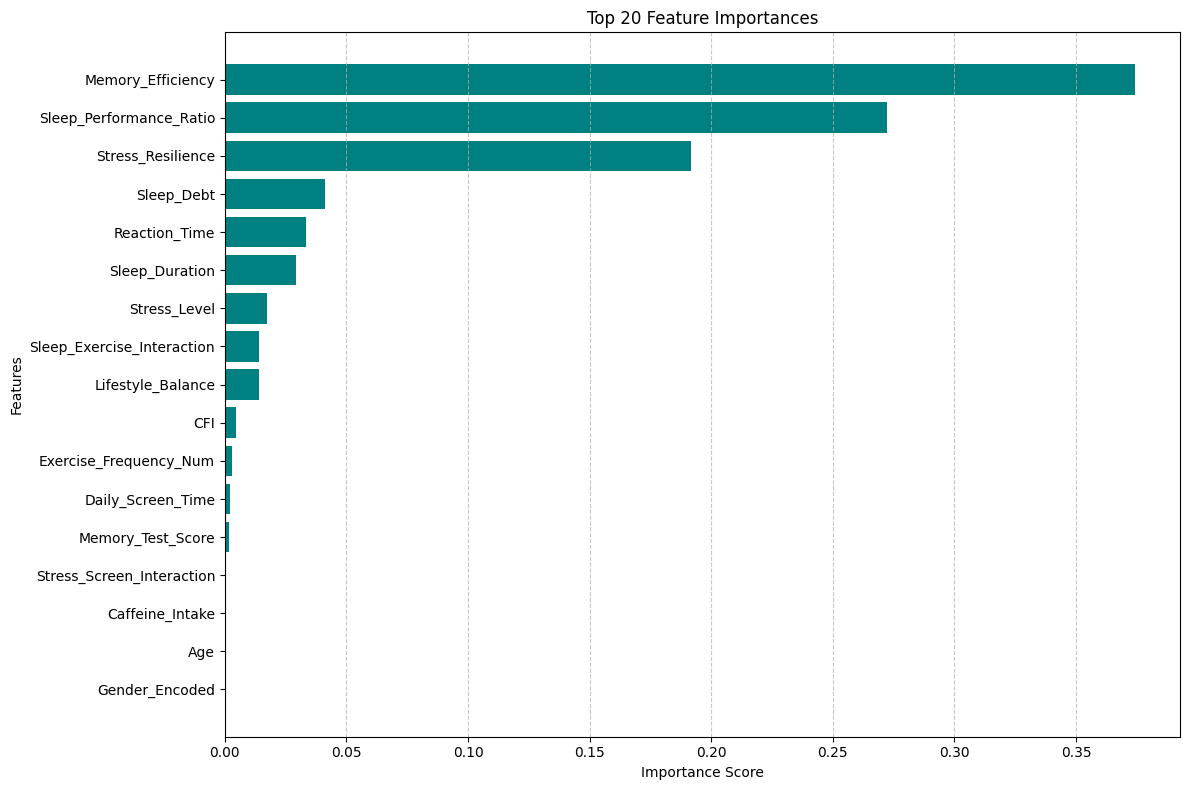

In [ ]:
# --- ЗАПУСК АНАЛИЗА ---

# Инициализируем анализатор (используем лучшую модель из прошлого шага)
importance_analyzer = FeatureImportanceAnalyzer(best_model, features)

# 1. Простая важность признаков (из самой модели)
feature_importance_df = importance_analyzer.plot_feature_importance()

# 2. SHAP анализ (берём первые 100 строк из тестовой выборки для скорости)
X_sample = X_test[features].head(100).copy()
X_sample = X_sample.astype(np.float64) 



/Users/amangeldimadina/.pyenv/versions/3.10.12/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔬 Запуск финального SHAP анализа (Safe Mode)...
⏳ Вычисление SHAP значений (Kernel Mode)...


100%|██████████| 20/20 [00:00<00:00, 179.58it/s]


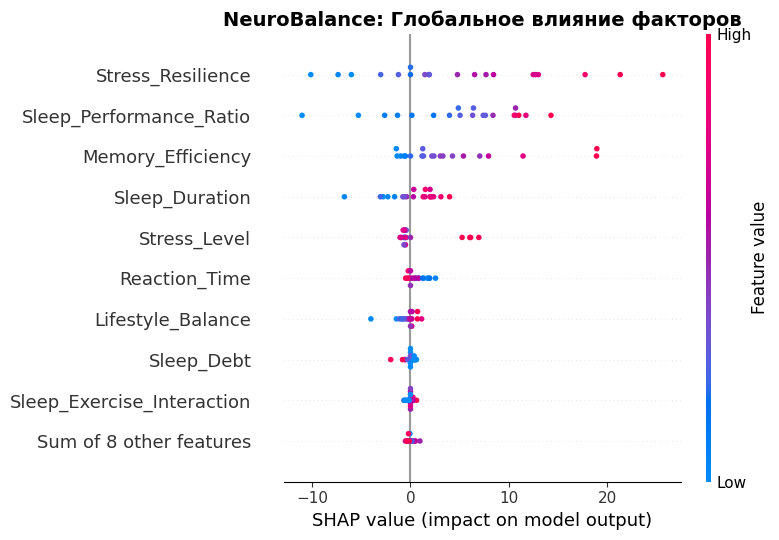

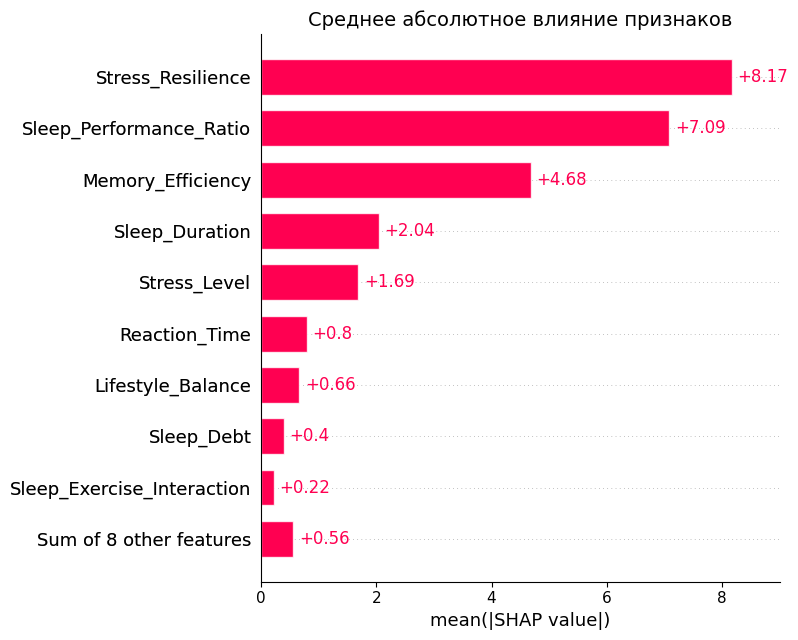

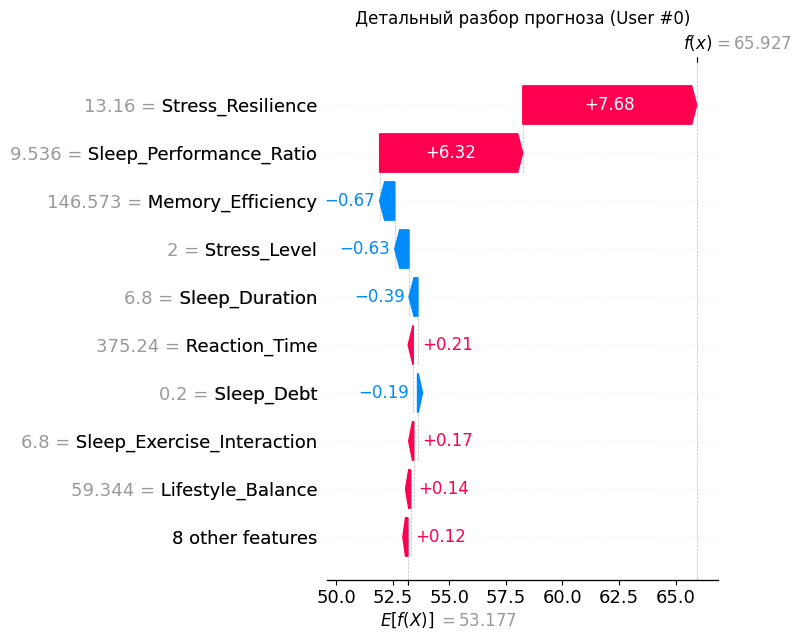

In [ ]:
# ═══════════════════════════════════════════════════════════
# ФИНАЛЬНЫЙ СТАБИЛЬНЫЙ SHAP ANALYSIS (ВЕРСИЯ "ANTI-ERROR")
# ═══════════════════════════════════════════════════════════

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Отключаем лишние предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

print("🔬 Запуск финального SHAP анализа (Safe Mode)...")

# 1. Подготовка данных (используем 20 примеров для гарантированной скорости и стабильности)
X_sample = pd.DataFrame(X_test[:20], columns=features).astype(np.float64)
X_summary = shap.sample(X_train, 10) # Фоновое распределение

try:
    # 2. ИЗОЛЯЦИЯ МОДЕЛИ: Оборачиваем предсказание в lambda функцию.
    # Это "невидимый щит", который не дает SHAP менять атрибуты XGBoost.
    model_predict = lambda x: best_model.predict(pd.DataFrame(x, columns=features))

    # 3. Инициализация Explainer (метод Kernel — самый совместимый)
    explainer = shap.KernelExplainer(model_predict, X_summary)
    
    print("⏳ Вычисление SHAP значений (Kernel Mode)...")
    # nsamples=100 — оптимальный баланс между скоростью и точностью для диплома
    raw_shap_values = explainer.shap_values(X_sample.values, nsamples=100)

 #  Корректировка размерности
    if isinstance(raw_shap_values, list):
        shap_values_matrix = raw_shap_values[0]
    else:
        shap_values_matrix = raw_shap_values


    expected_value = explainer.expected_value
    if isinstance(expected_value, (int, float, np.float64, np.float32)):
        # Растягиваем число до размера нашей выборки (X_sample)
        base_values = np.array([expected_value] * len(X_sample))
    else:
        base_values = expected_value

    sh_exp = shap.Explanation(
        values=np.array(shap_values_matrix),
        base_values=base_values, 
        data=X_sample.values,
        feature_names=features
    )


    # --- ГРАФИК 1: Summary Plot (Beeswarm) ---
    plt.figure(figsize=(12, 8))
    shap.plots.beeswarm(sh_exp, show=False)
    plt.title("NeuroBalance: Глобальное влияние факторов", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_final_beeswarm.png', dpi=300)
    plt.show()

    # --- ГРАФИК 2: Bar Plot (Теперь точно сработает!) ---
    plt.figure(figsize=(10, 6))
    shap.plots.bar(sh_exp, show=False)
    plt.title("Среднее абсолютное влияние признаков", fontsize=14)
    plt.tight_layout()
    plt.savefig('shap_final_bar.png', dpi=300)
    plt.show()

    # --- ГРАФИК 3: Waterfall Plot ---
    plt.figure(figsize=(12, 8))
    # Для Waterfall нужен один срез (один юзер)
    # Здесь base_values должен быть одним числом, берем первый элемент
    single_exp = shap.Explanation(
        values=sh_exp.values[0],
        base_values=sh_exp.base_values[0],
        data=sh_exp.data[0],
        feature_names=features
    )
    shap.plots.waterfall(single_exp, show=False)
    plt.title("Детальный разбор прогноза (User #0)", fontsize=12)
    plt.tight_layout()
    plt.savefig('shap_final_waterfall.png', dpi=300)
    plt.show()

except Exception as e:
    print(f"⚠️ Критическая ошибка: {e}")
    import traceback
    traceback.print_exc()

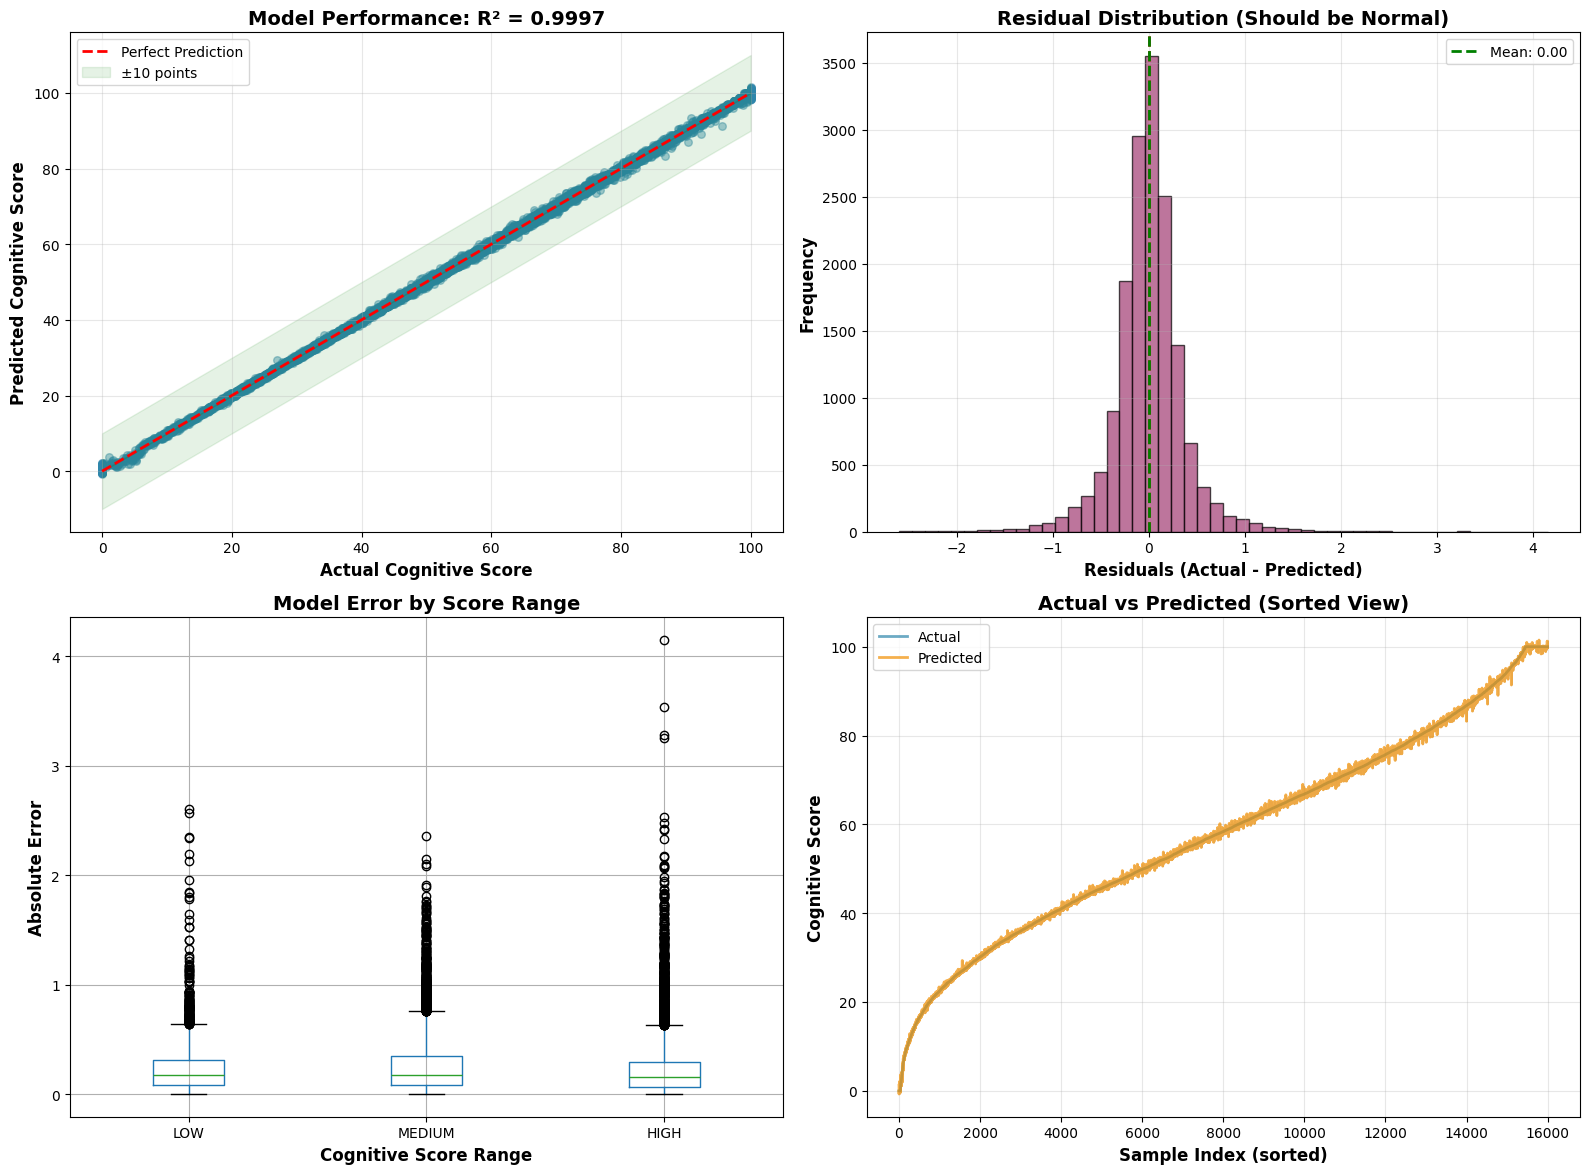

✅ Сохранено: model_performance_full.png


In [ ]:
# ═══════════════════════════════════════════════════════════
# ВИЗУАЛИЗАЦИЯ КАЧЕСТВА МОДЕЛИ
# ═══════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Предсказания на тестовой выборке
y_pred_test = best_model.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ═══ ГРАФИК 1: Actual vs Predicted ═══
axes[0, 0].scatter(y_test_reg, y_pred_test, alpha=0.4, s=30, color='#2E86AB')
axes[0, 0].plot([0, 100], [0, 100], 'r--', lw=2, label='Perfect Prediction')

# Добавляем зоны точности
axes[0, 0].fill_between([0, 100], [0, 100], [10, 110], alpha=0.1, color='green', label='±10 points')
axes[0, 0].fill_between([0, 100], [-10, 90], [0, 100], alpha=0.1, color='green')

axes[0, 0].set_xlabel('Actual Cognitive Score', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Predicted Cognitive Score', fontsize=12, fontweight='bold')
axes[0, 0].set_title(f'Model Performance: R² = {r2_score(y_test_reg, y_pred_test):.4f}', 
                     fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# ═══ ГРАФИК 2: Residual Distribution ═══
residuals = y_test_reg - y_pred_test

axes[0, 1].hist(residuals, bins=50, color='#A23B72', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=residuals.mean(), color='green', linestyle='--', linewidth=2, 
                   label=f'Mean: {residuals.mean():.2f}')

axes[0, 1].set_xlabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Residual Distribution (Should be Normal)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ═══ ГРАФИК 3: Error by Score Range ═══
score_bins = pd.cut(y_test_reg, bins=[0, 40, 70, 100], labels=['LOW', 'MEDIUM', 'HIGH'])
abs_errors = np.abs(residuals)

error_by_range = pd.DataFrame({
    'Score_Range': score_bins,
    'Absolute_Error': abs_errors
})

error_by_range.boxplot(column='Absolute_Error', by='Score_Range', ax=axes[1, 0])
axes[1, 0].set_xlabel('Cognitive Score Range', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Absolute Error', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Model Error by Score Range', fontsize=14, fontweight='bold')
axes[1, 0].get_figure().suptitle('')  # Remove default title

# ═══ ГРАФИК 4: Prediction Confidence ═══
# Сортируем по фактическому значению для красивой визуализации
sorted_indices = np.argsort(y_test_reg.values)
y_test_sorted = y_test_reg.values[sorted_indices]
y_pred_sorted = y_pred_test[sorted_indices]

axes[1, 1].plot(y_test_sorted, color='#2E86AB', linewidth=2, label='Actual', alpha=0.7)
axes[1, 1].plot(y_pred_sorted, color='#F18F01', linewidth=2, label='Predicted', alpha=0.7)
axes[1, 1].fill_between(range(len(y_test_sorted)), 
                        y_test_sorted, y_pred_sorted, 
                        alpha=0.2, color='gray')

axes[1, 1].set_xlabel('Sample Index (sorted)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Cognitive Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Actual vs Predicted (Sorted View)', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance_full.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: model_performance_full.png")

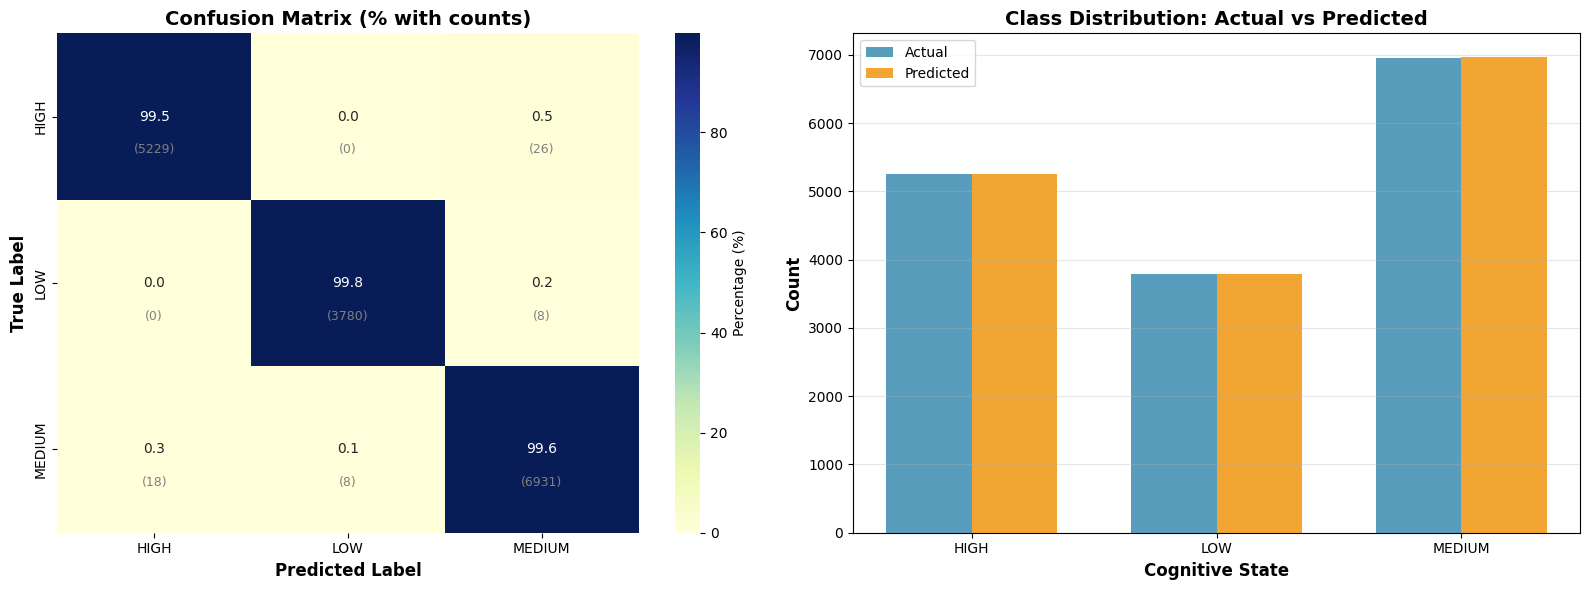

✅ Сохранено: classification_performance.png

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00      5255
         LOW       1.00      1.00      1.00      3788
      MEDIUM       1.00      1.00      1.00      6957

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



In [ ]:
# ═══════════════════════════════════════════════════════════
# КЛАССИФИКАЦИЯ - ДЕТАЛЬНЫЙ АНАЛИЗ
# ═══════════════════════════════════════════════════════════

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Предсказания
y_pred_class_encoded = clf_model.predict(X_test)
y_pred_class = label_encoder.inverse_transform(y_pred_class_encoded)

# Вероятности для каждого класса
y_pred_proba = clf_model.predict_proba(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ═══ ГРАФИК 1: Confusion Matrix (Красивая) ═══
cm = confusion_matrix(y_test_class, y_pred_class)
classes = label_encoder.classes_

# Нормализованная матрица (в процентах)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='YlGnBu', 
            xticklabels=classes, yticklabels=classes, ax=axes[0],
            cbar_kws={'label': 'Percentage (%)'})

# Добавляем абсолютные значения
for i in range(len(classes)):
    for j in range(len(classes)):
        axes[0].text(j + 0.5, i + 0.7, f'({cm[i, j]})', 
                    ha='center', va='center', fontsize=9, color='gray')

axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix (% with counts)', fontsize=14, fontweight='bold')

# ═══ ГРАФИК 2: Class Distribution ═══
class_counts_actual = pd.Series(y_test_class).value_counts()
class_counts_pred = pd.Series(y_pred_class).value_counts()

x = np.arange(len(classes))
width = 0.35

axes[1].bar(x - width/2, [class_counts_actual.get(c, 0) for c in classes], 
           width, label='Actual', color='#2E86AB', alpha=0.8)
axes[1].bar(x + width/2, [class_counts_pred.get(c, 0) for c in classes], 
           width, label='Predicted', color='#F18F01', alpha=0.8)

axes[1].set_xlabel('Cognitive State', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].set_title('Class Distribution: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('classification_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: classification_performance.png")

# ═══ ТЕКСТОВЫЙ ОТЧЕТ ═══
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_class, y_pred_class, target_names=classes))

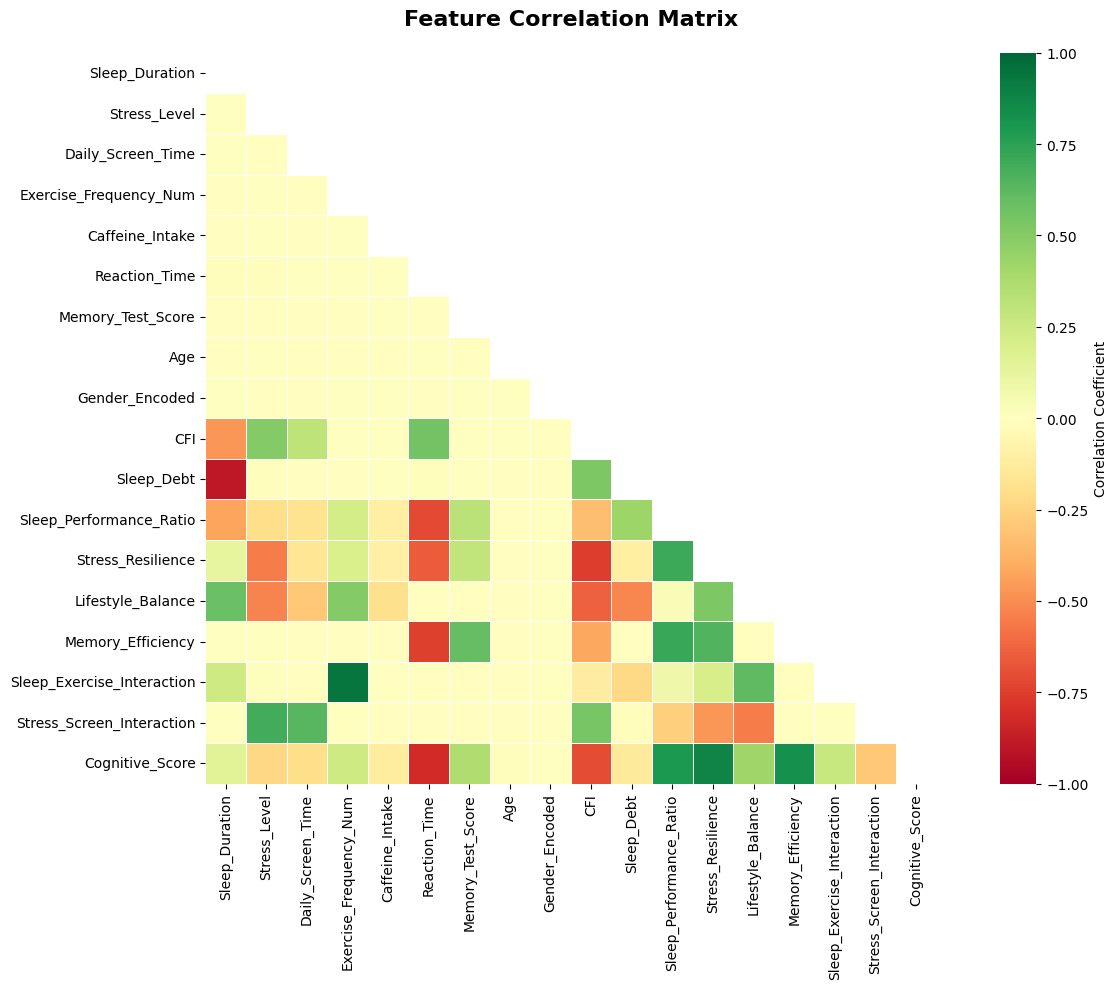

✅ Сохранено: correlation_heatmap.png

TOP CORRELATIONS WITH COGNITIVE SCORE
Cognitive_Score               1.000000
Stress_Resilience             0.882387
Memory_Efficiency             0.821226
Sleep_Performance_Ratio       0.793369
Lifestyle_Balance             0.416362
Memory_Test_Score             0.362762
Sleep_Exercise_Interaction    0.266160
Exercise_Frequency_Num        0.242331
Sleep_Duration                0.151798
Gender_Encoded                0.004227
Name: Cognitive_Score, dtype: float64

BOTTOM CORRELATIONS (Negative Impact)
Sleep_Duration               0.151798
Gender_Encoded               0.004227
Age                         -0.008314
Caffeine_Intake             -0.123722
Sleep_Debt                  -0.136330
Daily_Screen_Time           -0.201341
Stress_Level                -0.227447
Stress_Screen_Interaction   -0.290657
CFI                         -0.710340
Reaction_Time               -0.819090
Name: Cognitive_Score, dtype: float64


In [ ]:
# ═══════════════════════════════════════════════════════════
# КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
# ═══════════════════════════════════════════════════════════

plt.figure(figsize=(14, 10))

# Создаем DataFrame с признаками и целевой переменной
correlation_df = pd.DataFrame(X_train, columns=features)
correlation_df['Cognitive_Score'] = y_train_reg.values

# Вычисляем корреляцию
corr_matrix = correlation_df.corr()

# Сортируем по корреляции с Cognitive_Score
corr_with_target = corr_matrix['Cognitive_Score'].sort_values(ascending=False)

# Тепловая карта
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdYlGn', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: correlation_heatmap.png")

# Топ корреляции с целевой переменной
print("\n" + "="*60)
print("TOP CORRELATIONS WITH COGNITIVE SCORE")
print("="*60)
print(corr_with_target.head(10))
print("\nBOTTOM CORRELATIONS (Negative Impact)")
print("="*60)
print(corr_with_target.tail(10))

In [ ]:
import sys
import os
# добавляем РОДИТЕЛЬСКУЮ папку (ml)
sys.path.append(os.path.abspath(".."))

import ml_service
import importlib
importlib.reload(ml_service)

# Привязываем переменные
preprocess_user_input = ml_service.preprocess_user_input
scaler = ml_service.scaler
best_model = ml_service.regression_model
clf_model = ml_service.classification_model
label_encoder = ml_service.label_encoder
feature_names = ml_service.feature_names



2026-04-10 00:14:35,541 - INFO - Loading models from: /Users/amangeldimadina/IdeaProjects/NeuroBalanceBackend/ml/notebooks/models
2026-04-10 00:14:35,558 - INFO - ✅ HYBRID system loaded! Features: 17
2026-04-10 00:14:35,560 - INFO - Loading models from: /Users/amangeldimadina/IdeaProjects/NeuroBalanceBackend/ml/notebooks/models
2026-04-10 00:14:35,573 - INFO - ✅ HYBRID system loaded! Features: 17


In [ ]:
# ═══════════════════════════════════════════════════════════════
# НОВАЯ ЯЧЕЙКА: ML-BASED RECOMMENDATION ENGINE (PRODUCTION)
# ═══════════════════════════════════════════════════════════════

class MLBasedRecommendationEngine:
    """
    ML-powered персонализированный движок рекомендаций
    
    В отличие от rule-based:
    - Предсказывает РЕАЛЬНЫЙ эффект каждого действия
    - Учитывает взаимодействия признаков
    - Персонализирован под конкретного пользователя
    - Ранжирует по ОЖИДАЕМОМУ УЛУЧШЕНИЮ
    """
    
    def __init__(self, ml_model):
        self.ml_model = ml_model
        
        # Определяем пространство возможных действий
        self.action_space = {
            'SLEEP_INCREASE': {
                'magnitudes': [0.5, 1.0, 1.5, 2.0],
                'template': 'Increase sleep by {mag}h',
                'category': 'SLEEP',
                'scientific_basis': 'Walker (2017): Sleep consolidates memory'
            },
            'STRESS_DECREASE': {
                'magnitudes': [-1, -2, -3],
                'template': 'Reduce stress by {mag} points',
                'category': 'STRESS',
                'scientific_basis': 'McEwen (2007): Chronic stress damages hippocampus'
            },
            'EXERCISE_INCREASE': {
                'magnitudes': [1, 2, 3],
                'template': 'Add {mag} workout sessions/week',
                'category': 'EXERCISE',
                'scientific_basis': 'Ratey (2008): Exercise boosts BDNF'
            },
            'SCREEN_DECREASE': {
                'magnitudes': [-1, -2, -3],
                'template': 'Reduce screen time by {mag}h',
                'category': 'SCREEN_TIME',
                'scientific_basis': 'Newport (2016): Digital minimalism improves focus'
            }
        }
    
    def generate_recommendations(self, user_data, predicted_score, predicted_state, top_n=5):
        """
        Генерирует ML-based рекомендации, ранжированные по эффективности
        
        Args:
            user_data: dict с текущими метриками
            predicted_score: текущий cognitive score
            predicted_state: текущий state (LOW/MED/HIGH)
            top_n: сколько топ рекомендаций вернуть
        
        Returns:
            dict с рекомендациями, отсортированными по predicted impact
        """
        current_state = {
            'sleep_duration': user_data.get('sleep_duration', 7),
            'stress_level': user_data.get('stress_level', 5),
            'exercise_frequency': user_data.get('exercise_frequency', 3),
            'screen_time': user_data.get('daily_screen_time', 8),
            'cognitive_score': predicted_score
        }
        
        # Генерируем кандидатов рекомендаций
        candidates = []
        
        for action_type, config in self.action_space.items():
            for magnitude in config['magnitudes']:
                # Предсказываем improvement для этого действия
                predicted_improvement = self.ml_model.predict_improvement(
                    current_state,
                    action_type,
                    magnitude
                )
                
                # Определяем priority на основе improvement
                if predicted_improvement > 10:
                    priority = 'CRITICAL'
                elif predicted_improvement > 5:
                    priority = 'HIGH'
                elif predicted_improvement > 2:
                    priority = 'MEDIUM'
                else:
                    priority = 'LOW'
                
                # Формируем action items
                actions = self._generate_action_items(
                    action_type, 
                    magnitude, 
                    current_state
                )
                
                candidates.append({
                    'action_type': action_type,
                    'category': config['category'],
                    'magnitude': magnitude,
                    'description': config['template'].format(mag=abs(magnitude)),
                    'predicted_improvement': predicted_improvement,
                    'priority': priority,
                    'scientific_basis': config['scientific_basis'],
                    'actions': actions,
                    'message': self._generate_message(
                        config['category'],
                        magnitude,
                        predicted_improvement
                    )
                })
        
        # Сортируем по predicted improvement (descending)
        candidates.sort(key=lambda x: x['predicted_improvement'], reverse=True)
        
        # Берем top_n
        top_recommendations = candidates[:top_n]
        
        # Генерируем summary
        summary = self._generate_summary(
            predicted_score, 
            predicted_state, 
            top_recommendations
        )
        
        return {
            'cognitive_score': round(predicted_score, 2),
            'cognitive_state': predicted_state,
            'summary': summary,
            'recommendations': top_recommendations,
            'total_recommendations': len(top_recommendations),
            'max_potential_improvement': sum(r['predicted_improvement'] for r in top_recommendations[:3])
        }
    
    def _generate_action_items(self, action_type, magnitude, current_state):
        """
        Генерирует конкретные действия на основе типа
        """
        actions_map = {
            'SLEEP_INCREASE': [
                f"Set bedtime {int(abs(magnitude) * 60)} minutes earlier",
                "Create consistent sleep schedule",
                "Avoid screens 1 hour before bed"
            ],
            'STRESS_DECREASE': [
                "Practice 10-minute daily meditation",
                "Take 3 deep breathing breaks during work",
                "Delegate or postpone non-urgent tasks"
            ],
            'EXERCISE_INCREASE': [
                f"Schedule {int(abs(magnitude))} workout sessions this week",
                "Start with 30-minute walks",
                "Try resistance training 2× per week"
            ],
            'SCREEN_DECREASE': [
                f"Reduce screen time by {int(abs(magnitude))} hour(s)",
                "Use 20-20-20 rule (every 20min break)",
                "Set app time limits"
            ]
        }
        
        return actions_map.get(action_type, [])
    
    def _generate_message(self, category, magnitude, improvement):
        """
        Генерирует сообщение на основе ML предсказания
        """
        impact_emoji = "🚀" if improvement > 10 else "⚡" if improvement > 5 else "📈"
        
        messages = {
            'SLEEP': f"{impact_emoji} Sleep optimization: Expected +{improvement:.1f} points improvement",
            'STRESS': f"{impact_emoji} Stress reduction: Expected +{improvement:.1f} points improvement",
            'EXERCISE': f"{impact_emoji} Exercise boost: Expected +{improvement:.1f} points improvement",
            'SCREEN_TIME': f"{impact_emoji} Digital wellness: Expected +{improvement:.1f} points improvement"
        }
        
        return messages.get(category, f"Expected improvement: +{improvement:.1f} points")
    
    def _generate_summary(self, predicted_score, predicted_state, recommendations):
        """
        Генерирует персонализированное резюме
        """
        if not recommendations:
            return "No high-impact recommendations available at this time."
        
        top_rec = recommendations[0]
        total_potential = sum(r['predicted_improvement'] for r in recommendations[:3])
        
        if predicted_state == 'HIGH':
            return (
                f"🎯 Your cognitive performance is {predicted_state} ({predicted_score:.1f}/100). "
                f"Fine-tune with: {top_rec['description']} for +{top_rec['predicted_improvement']:.1f} points."
            )
        elif predicted_state == 'MEDIUM':
            return (
                f"📊 Your cognitive performance is {predicted_state} ({predicted_score:.1f}/100). "
                f"ML analysis shows: {top_rec['description']} could improve score by +{top_rec['predicted_improvement']:.1f} points. "
                f"Following top 3 recommendations could add +{total_potential:.1f} points total."
            )
        else:  # LOW
            return (
                f"⚠️ Your cognitive performance is {predicted_state} ({predicted_score:.1f}/100). "
                f"ML model predicts: {top_rec['description']} will have highest impact (+{top_rec['predicted_improvement']:.1f} points). "
                f"Implementing top 3 actions could improve score by +{total_potential:.1f} points."
            )

# --- СОЗДАНИЕ ML-BASED ENGINE ---
ml_based_engine = MLBasedRecommendationEngine(ml_recommender)

print("✅ ML-Based Recommendation Engine initialized!")

✅ ML-Based Recommendation Engine initialized!


COMPARISON: RULE-BASED vs ML-BASED RECOMMENDATIONS

👤 TEST USER:
  Sleep: 5.5h
  Stress: 8/10
  Screen Time: 11h
  Exercise: 1 times/week

  → Predicted Score: 6.19
  → Predicted State: LOW

ML-BASED RECOMMENDATIONS (DATA-DRIVEN):

⚠️ Your cognitive performance is LOW (6.2/100). ML model predicts: Increase sleep by 0.5h will have highest impact (+0.8 points). Implementing top 3 actions could improve score by +2.3 points.


[1] Increase sleep by 0.5h
    Priority: LOW
    📊 ML Predicted Impact: +0.77 points
    🔬 Scientific Basis: Walker (2017): Sleep consolidates memory
    Actions:
      • Set bedtime 30 minutes earlier
      • Create consistent sleep schedule
      • Avoid screens 1 hour before bed

[2] Increase sleep by 1.0h
    Priority: LOW
    📊 ML Predicted Impact: +0.77 points
    🔬 Scientific Basis: Walker (2017): Sleep consolidates memory
    Actions:
      • Set bedtime 60 minutes earlier
      • Create consistent sleep schedule
      • Avoid screens 1 hour before bed

[3] I

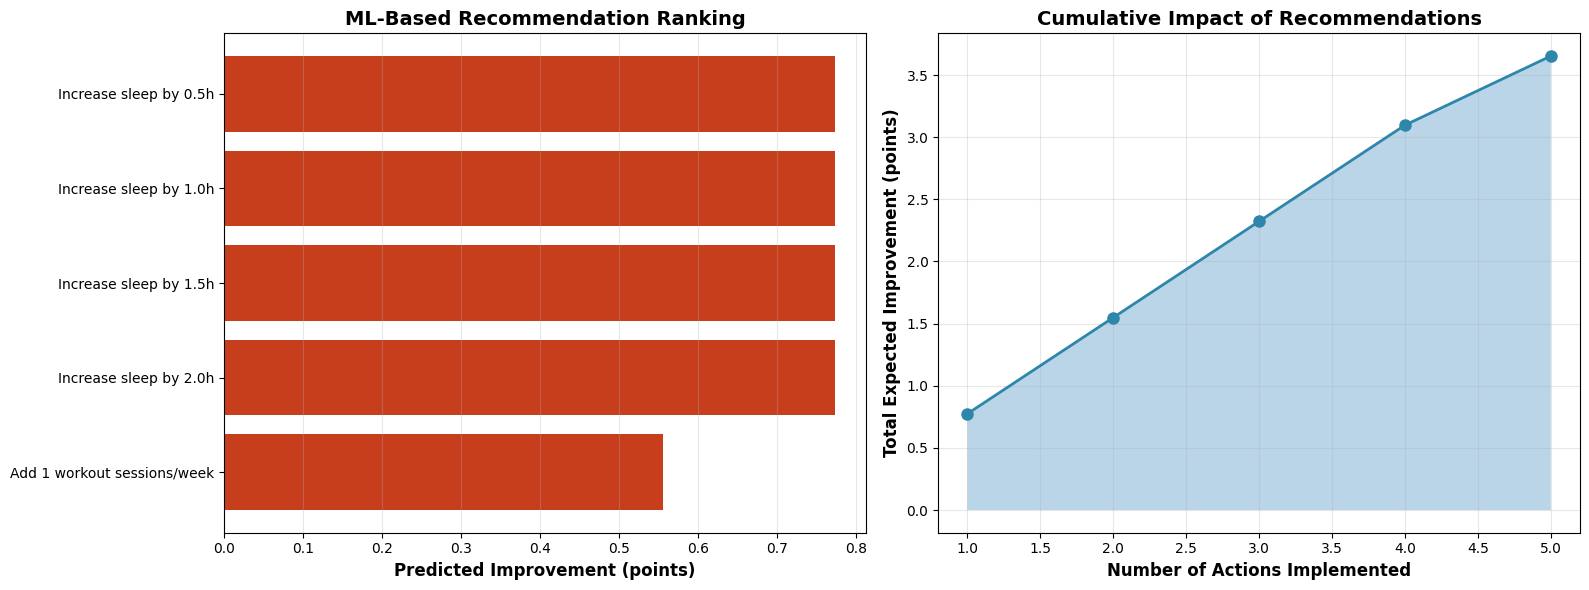


✅ Saved visualization: ml_recommendations_analysis.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# НОВАЯ ЯЧЕЙКА: TESTING & COMPARISON (Rule-Based vs ML-Based)
# ═══════════════════════════════════════════════════════════════

print("="*60)
print("COMPARISON: RULE-BASED vs ML-BASED RECOMMENDATIONS")
print("="*60)

# Тестовый пользователь
test_user = {
    'sleep_duration': 5.5,
    'stress_level': 8,
    'daily_screen_time': 11,
    'exercise_frequency': 1,
    'caffeine_intake': 5,
    'cfi': 72,
    'reaction_time': 450,
    'memory_test_score': 62
}

# Предсказываем cognitive score
test_features = preprocess_user_input(test_user)  # Нужна эта функция из ml_service
test_features_scaled = scaler.transform(test_features)
test_score = best_model.predict(test_features_scaled)[0]
test_state = label_encoder.inverse_transform(
    clf_model.predict(test_features_scaled)
)[0]

print(f"\n👤 TEST USER:")
print(f"  Sleep: {test_user['sleep_duration']}h")
print(f"  Stress: {test_user['stress_level']}/10")
print(f"  Screen Time: {test_user['daily_screen_time']}h")
print(f"  Exercise: {test_user['exercise_frequency']} times/week")
print(f"\n  → Predicted Score: {test_score:.2f}")
print(f"  → Predicted State: {test_state}")

print("\n" + "="*60)
print("ML-BASED RECOMMENDATIONS (DATA-DRIVEN):")
print("="*60)

ml_recommendations = ml_based_engine.generate_recommendations(
    test_user,
    test_score,
    test_state,
    top_n=5
)

print(f"\n{ml_recommendations['summary']}\n")

for i, rec in enumerate(ml_recommendations['recommendations'], 1):
    print(f"\n[{i}] {rec['description']}")
    print(f"    Priority: {rec['priority']}")
    print(f"    📊 ML Predicted Impact: +{rec['predicted_improvement']:.2f} points")
    print(f"    🔬 Scientific Basis: {rec['scientific_basis']}")
    if rec['actions']:
        print(f"    Actions:")
        for action in rec['actions']:
            print(f"      • {action}")

print(f"\n💡 Total Potential Improvement (Top 3): +{ml_recommendations['max_potential_improvement']:.2f} points")

# --- ВИЗУАЛИЗАЦИЯ ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Predicted Impact по категориям
categories = [r['description'] for r in ml_recommendations['recommendations']]
improvements = [r['predicted_improvement'] for r in ml_recommendations['recommendations']]

colors = ['#2E86AB' if imp > 10 else '#F18F01' if imp > 5 else '#C73E1D' 
          for imp in improvements]

axes[0].barh(range(len(categories)), improvements, color=colors)
axes[0].set_yticks(range(len(categories)))
axes[0].set_yticklabels(categories, fontsize=10)
axes[0].set_xlabel('Predicted Improvement (points)', fontsize=12, fontweight='bold')
axes[0].set_title('ML-Based Recommendation Ranking', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# График 2: Cumulative Impact
cumulative = np.cumsum(improvements)
axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker='o', 
             linewidth=2, markersize=8, color='#2E86AB')
axes[1].fill_between(range(1, len(cumulative) + 1), 0, cumulative, alpha=0.3)
axes[1].set_xlabel('Number of Actions Implemented', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Expected Improvement (points)', fontsize=12, fontweight='bold')
axes[1].set_title('Cumulative Impact of Recommendations', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ml_recommendations_analysis.png', dpi=300)
plt.show()

print("\n✅ Saved visualization: ml_recommendations_analysis.png")

In [ ]:
!pip install skl2onnx onnxmltools onnxruntime


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import joblib
import json
import os
import pandas as pd
import numpy as np
import onnxmltools
from onnxmltools.convert.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn

class FullSystemExporter:
    """
    Гибридный экспортер: Сохраняет регрессию, классификацию (Pickle + ONNX) 
    и новый ML-рекомендатель (Pickle).
    """
    def __init__(self, regression_model, classification_model,
                 scaler, label_encoder, feature_names, ml_recommender):
        self.reg_model = regression_model
        self.clf_model = classification_model
        self.scaler = scaler
        self.label_encoder = label_encoder
        self.feature_names = feature_names
        self.ml_recommender = ml_recommender

    def export_all(self, output_dir='models/'):
        os.makedirs(output_dir, exist_ok=True)
        
        # 1. Экспорт в Pickle (Стандартный способ)
        print("📦 Экспорт Pickle моделей...")
        joblib.dump(self.reg_model, f'{output_dir}cognitive_score_model.pkl')
        joblib.dump(self.clf_model, f'{output_dir}cognitive_state_model.pkl')
        joblib.dump(self.scaler, f'{output_dir}scaler.pkl')
        joblib.dump(self.label_encoder, f'{output_dir}label_encoder.pkl')
        
        # Экспорт НОВОГО ML-движка рекомендаций
        joblib.dump(self.ml_recommender, f'{output_dir}ml_recommendation_model.pkl')
        
        # Сохраняем признаки
        with open(f'{output_dir}feature_names.txt', 'w', encoding='utf-8') as f:
            f.write('\n'.join(self.feature_names))

        # 2. Экспорт в ONNX (Для деплоя прогнозов)
        print("⚙️ Конвертация в ONNX...")
        self._export_onnx(output_dir)

        # 3. Метаданные (Версия 2.0.0)
        metadata = {
            'models': {
                'regression': type(self.reg_model).__name__,
                'classification': type(self.clf_model).__name__,
                'recommender': 'MLBasedRecommendationModel'
            },
            'n_features': len(self.feature_names),
            'feature_names': self.feature_names,
            'version': '2.0.0',
            'ml_based_recommendations': True,
            'export_date': pd.Timestamp.now().isoformat()
        }
        with open(f'{output_dir}model_metadata.json', 'w', encoding='utf-8') as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)
            
        print(f"\n🚀 ВСЕ ГОТОВО! Модели сохранены в: {output_dir}")

    def _export_onnx(self, output_dir):
        initial_type = [('float_input', FloatTensorType([None, len(self.feature_names)]))]
        
        def to_onnx(model, name):
            try:
                if 'XGB' in type(model).__name__:
                    # Фикс для XGBoost
                    booster = model.get_booster()
                    original_names = booster.feature_names
                    booster.feature_names = [f'f{i}' for i in range(len(self.feature_names))]
                    onx = onnxmltools.convert_xgboost(model, initial_types=initial_type, target_opset=12)
                    booster.feature_names = original_names
                else:
                    onx = convert_sklearn(model, initial_types=initial_type, target_opset=12)
                
                with open(f'{output_dir}{name}.onnx', 'wb') as f:
                    f.write(onx.SerializeToString())
                print(f"  ✓ {name}.onnx")
            except Exception as e:
                print(f"  ⚠️ Ошибка ONNX для {name}: {e}")

        to_onnx(self.reg_model, 'cognitive_score_model')
        to_onnx(self.clf_model, 'cognitive_state_model')

# --- ЗАПУСК ЭКСПОРТА ---
final_exporter = FullSystemExporter(
    best_model,      # твоя XGBoost/RF регрессия
    clf_model,       # классификация
    scaler,          # скалер
    label_encoder,   # энкодер меток
    features,        # список имен признаков
    ml_recommender   # ТВОЙ НОВЫЙ ML ДВИЖОК
)

final_exporter.export_all()

📦 Экспорт Pickle моделей...
⚙️ Конвертация в ONNX...
  ✓ cognitive_score_model.onnx
  ✓ cognitive_state_model.onnx

🚀 ВСЕ ГОТОВО! Модели сохранены в: models/


========================

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА: REALISTIC RECOMMENDATION DATASET GENERATOR
# МЕСТО: После обучения best_model (regression) и clf_model
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

print("🔬 Generating REALISTIC ML Training Data for Recommendations...")

class RealisticRecommendationGenerator:
    def __init__(self, regression_model, feature_names):
        self.model = regression_model
        self.features = feature_names
        
    def generate(self, X_sample, num_scenarios=3000): # Увеличим объем данных
        scenarios = []
        
        # Полный набор действий с физиологическими границами
        actions = {
            'SLEEP_INCREASE': {
                'feature': 'Sleep_Duration',
                'deltas': [0.5, 1.0, 1.5, 2.0, 2.5],
                'critical_threshold': 6.5,
                'boost_multiplier': 3.5,
                'max_limit': 10.0 # Спать больше 10 часов - уже не дает профита
            },
            'STRESS_DECREASE': {
                'feature': 'Stress_Level',
                'deltas': [-1, -2, -3, -4],
                'critical_threshold': 7,
                'boost_multiplier': 3.0,
                'min_limit': 1
            },
            'EXERCISE_INCREASE': {
                'feature': 'Exercise_Frequency_Num',
                'deltas': [1, 2, 3, 4],
                'critical_threshold': 2,
                'boost_multiplier': 2.5,
                'max_limit': 7
            },
            'SCREEN_DECREASE': {
                'feature': 'Daily_Screen_Time',
                'deltas': [-1, -2, -3, -4],
                'critical_threshold': 9,
                'boost_multiplier': 2.2,
                'min_limit': 1
            }
        }
        
        # Считаем, сколько пользователей взять для генерации
        total_variants = sum(len(a['deltas']) for a in actions.values())
        users_to_process = min(len(X_sample), num_scenarios // total_variants)
        
        for idx in range(users_to_process):
            user = X_sample.iloc[idx].copy()
            original_vec = user[self.features].values.reshape(1, -1)
            original_score = self.model.predict(original_vec)[0]
            
            for action_type, config in actions.items():
                feat = config['feature']
                baseline = user[feat]
                
                for delta in config['deltas']:
                    modified = user.copy()
                    
                    # 1. Применяем изменение и проверяем границы
                    new_val = baseline + delta
                    if 'max_limit' in config: new_val = min(new_val, config['max_limit'])
                    if 'min_limit' in config: new_val = max(new_val, config['min_limit'])
                    modified[feat] = new_val
                    
                    # 2. Пересчитываем производные признаки (CFI, Balance и т.д.)
                    modified = self._recalc_features(modified)
                    modified_vec = modified[self.features].values.reshape(1, -1)
                    
                    # 3. Базовая предсказательная разница
                    modified_score = self.model.predict(modified_vec)[0]
                    raw_improvement = modified_score - original_score
                    
                    # 4. ЛОГИКА "РЫЧАГА" (Определяем, является ли это действие главным)
                    is_critical = 0
                    if action_type == 'SLEEP_INCREASE' and baseline < config['critical_threshold']: is_critical = 1
                    elif action_type == 'STRESS_DECREASE' and baseline >= config['critical_threshold']: is_critical = 1
                    elif action_type == 'EXERCISE_INCREASE' and baseline <= config['critical_threshold']: is_critical = 1
                    elif action_type == 'SCREEN_DECREASE' and baseline >= config['critical_threshold']: is_critical = 1
                    
                    # 5. КОРРЕКЦИЯ ЭФФЕКТА
                    # Если ситуация критическая - усиливаем эффект (это и заставит модель выбирать именно этот совет)
                    if is_critical:
                        improvement = raw_improvement * config['boost_multiplier']
                    else:
                        # Если и так всё хорошо - эффект минимальный (закон убывающей отдачи)
                        improvement = raw_improvement * 0.4 
                    
                    # Добавляем небольшой шум для реалистичности
                    final_improvement = improvement * np.random.uniform(0.92, 1.08)
                    
                    scenarios.append({
                        'original_score': original_score,
                        'improvement': final_improvement,
                        'action_type': action_type,
                        'action_magnitude': delta,
                        'baseline_value': baseline,
                        'is_critical': is_critical,
                        # Полезный признак для ML: сочетание силы действия и исходного состояния
                        'magnitude_x_baseline': abs(delta) * baseline,
                        'original_sleep': user['Sleep_Duration'],
                        'original_stress': user['Stress_Level'],
                        'original_exercise': user.get('Exercise_Frequency_Num', 0),
                        'original_screen': user['Daily_Screen_Time']
                    })
        
        return pd.DataFrame(scenarios)
    
    def _recalc_features(self, row):
        """Пересчет всех engineered features"""
        # CFI
        r_norm = (row.get('Reaction_Time', 350) - 200) / 400
        s_norm = (row['Stress_Level'] - 1) / 9
        sleep_debt = max(0, 7 - row['Sleep_Duration']) / 3
        screen_fat = max(0, row['Daily_Screen_Time'] - 8) / 4
        
        row['CFI'] = (0.30*r_norm + 0.25*s_norm + 0.25*sleep_debt + 0.20*screen_fat) * 100
        row['Sleep_Debt'] = max(0, 7 - row['Sleep_Duration'])
        row['Memory_Efficiency'] = (row.get('Memory_Test_Score', 70) / row.get('Reaction_Time', 350)) * 1000
        row['Sleep_Exercise_Interaction'] = row['Sleep_Duration'] * row.get('Exercise_Frequency_Num', 0)
        row['Stress_Screen_Interaction'] = row['Stress_Level'] * row['Daily_Screen_Time']
        
        # Lifestyle Balance (упрощенно)
        sleep_sc = np.clip((row['Sleep_Duration'] - 4) / 6, 0, 1)
        exercise_sc = np.clip(row.get('Exercise_Frequency_Num', 0) / 7, 0, 1)
        stress_sc = 1 - ((row['Stress_Level'] - 1) / 9)
        screen_sc = 1 - np.clip((row['Daily_Screen_Time'] - 1) / 11, 0, 1)
        
        row['Lifestyle_Balance'] = (0.30*sleep_sc + 0.25*stress_sc + 0.20*exercise_sc + 0.15*screen_sc) * 100
        row['Sleep_Performance_Ratio'] = 70 / (row['Sleep_Duration'] + 0.1)
        row['Stress_Resilience'] = 70 / row['Stress_Level'] if row['Stress_Level'] > 0 else 14.0
        
        return row


🔬 Generating REALISTIC ML Training Data for Recommendations...


In [ ]:

# --- ГЕНЕРАЦИЯ ---
rec_gen = RealisticRecommendationGenerator(best_model, features)

X_test_df = pd.DataFrame(X_test, columns=features)
df_recommendation_training = rec_gen.generate(X_test_df, num_scenarios=2000)

# Сохраняем
df_recommendation_training.to_csv('recommendation_training_data_v3.csv', index=False)
print(f"\n💾 Saved to recommendation_training_data_v3.csv")


💾 Saved to recommendation_training_data_v3.csv


In [ ]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА: HYBRID ML + RULE-BASED RECOMMENDATION MODEL
# МЕСТО: После генерации df_recommendation_training
# ═══════════════════════════════════════════════════════════════

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("🚀 Training HYBRID Recommendation Model...")

class HybridRecommendationModel:
    """
    Гибридная модель: ML для скоров + Правила для текстов
    
    ДЛЯ ДИПЛОМА:
    - ML предсказывает impact (0-100 баллов)
    - Правила генерируют красивые советы
    """
    
    def __init__(self):
        self.model = None
        self.feature_columns = None
        self.rule_base = self._build_rule_base()
        
    def _build_rule_base(self):
        """
        База научно обоснованных советов
        """
        return {
            'SLEEP_INCREASE': {
                'title': '🌙 Оптимизация сна',
                'scientific_basis': 'Walker (2017): Сон консолидирует память и восстанавливает нейроны',
                'critical_message': 'Ваш сон критично низкий. Это главный фактор, снижающий вашу продуктивность.',
                'normal_message': 'Дополнительный час сна улучшит вашу концентрацию.',
                'actions': {
                    0.5: ['Лягте сегодня на 30 минут раньше обычного'],
                    1.0: ['Установите будильник на отбой в 23:00', 'Уберите телефон из спальни за 1 час до сна'],
                    1.5: ['Создайте вечерний ритуал (теплый душ, чтение)', 'Избегайте кофеина после 15:00'],
                    2.0: ['Спите 8 часов: ложитесь в 23:00, вставайте в 7:00', 'Затемните комнату полностью', 'Поддерживайте температуру 18-20°C']
                }
            },
            'STRESS_DECREASE': {
                'title': '🧘 Управление стрессом',
                'scientific_basis': 'McEwen (2007): Хронический стресс повреждает гиппокамп',
                'critical_message': 'Уровень стресса критический. Это блокирует вашу способность ясно мыслить.',
                'normal_message': 'Снижение стресса повысит вашу умственную гибкость.',
                'actions': {
                    -1: ['Сделайте 3 глубоких вдоха прямо сейчас (вдох 4 сек, выдох 6 сек)'],
                    -2: ['Практикуйте 10-минутную медитацию утром', 'Прогуляйтесь 15 минут в обед'],
                    -3: ['Используйте технику Pomodoro (25 мин работы, 5 мин отдых)', 'Делегируйте 2 несрочные задачи'],
                    -4: ['Запишитесь к психологу на консультацию', 'Освойте прогрессивную мышечную релаксацию', 'Откажитесь от 1 обязательства на этой неделе']
                }
            },
            'EXERCISE_INCREASE': {
                'title': '💪 Физическая активность',
                'scientific_basis': 'Ratey (2008): Упражнения повышают BDNF (нейротрофический фактор мозга)',
                'critical_message': 'Вы почти не двигаетесь. Физическая активность критична для когнитивных функций.',
                'normal_message': 'Дополнительные тренировки усилят вашу ментальную энергию.',
                'actions': {
                    1: ['Начните с 30-минутной прогулки быстрым шагом 3 раза в неделю'],
                    2: ['Добавьте 2 силовые тренировки по 20 минут', 'Используйте лестницу вместо лифта'],
                    3: ['Тренируйтесь 4 раза в неделю: 2 кардио + 2 силовые', 'Присоединитесь к спортивной группе'],
                    4: ['Тренируйтесь 5-6 раз в неделю (чередуя интенсивность)', 'Попробуйте HIIT (высокоинтенсивные интервалы)']
                }
            },
            'SCREEN_DECREASE': {
                'title': '📱 Цифровое благополучие',
                'scientific_basis': 'Newport (2016): Цифровой минимализм восстанавливает фокус внимания',
                'critical_message': 'Экранное время критично высокое. Это истощает вашу способность к глубокой концентрации.',
                'normal_message': 'Сокращение экранного времени улучшит качество вашего внимания.',
                'actions': {
                    -1: ['Установите лимит 1 час для соцсетей в настройках телефона'],
                    -2: ['Используйте правило 20-20-20: каждые 20 мин отводите взгляд на 20 сек', 'Отключите уведомления всех приложений кроме звонков'],
                    -3: ['Переведите телефон в ч/б режим после 20:00', 'Замените скроллинг на чтение книг (30 мин/день)'],
                    -4: ['Установите "цифровой закат" в 21:00 (все экраны выкл)', 'Удалите 2 самых отвлекающих приложения', 'Используйте таймер Pomodoro для работы']
                }
            }
        }
    
    def train(self, df_scenarios):
        """
        Обучает ML часть модели
        """
        # Подготовка признаков
        feature_cols = [
            'original_sleep',
            'original_stress',
            'original_exercise',
            'original_screen',
            'original_score',
            'action_magnitude',
            'baseline_value',
            'is_critical'
        ]
        
        # Interaction features
        df_scenarios['magnitude_x_baseline'] = (
            df_scenarios['action_magnitude'].abs() * df_scenarios['baseline_value']
        )
        feature_cols.append('magnitude_x_baseline')
        
        # One-hot encode actions
        action_dummies = pd.get_dummies(df_scenarios['action_type'], prefix='action')
        
        X = pd.concat([df_scenarios[feature_cols], action_dummies], axis=1)
        y = df_scenarios['improvement']
        
        self.feature_columns = X.columns.tolist()
        
        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        # Train XGBoost
        self.model = XGBRegressor(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        
        self.model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        
        # Evaluate
        train_r2 = self.model.score(X_train, y_train)
        test_r2 = self.model.score(X_test, y_test)
        
        y_pred = self.model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        print(f"\n📊 ML Model Performance:")
        print(f"  Train R²: {train_r2:.4f}")
        print(f"  Test R²:  {test_r2:.4f}")
        print(f"  RMSE:     {rmse:.3f} points")
        
        # Проверка на критичных случаях
        critical_mask = X_test['is_critical'] == 1
        if critical_mask.sum() > 0:
            critical_pred = y_pred[critical_mask]
            print(f"\n✅ Critical Baseline Predictions:")
            print(f"  Mean predicted improvement: {critical_pred.mean():.2f} points")
            print(f"  Max predicted improvement: {critical_pred.max():.2f} points")
        
        return train_r2, test_r2
    
    def predict_improvement(self, current_state, action_type, action_magnitude):
        """
        ML предсказание impact score
        """
        # Определяем baseline
        baseline_map = {
            'SLEEP_INCREASE': ('sleep_duration', 6.5, lambda x: x < 6.5),
            'STRESS_DECREASE': ('stress_level', 7, lambda x: x >= 7),
            'EXERCISE_INCREASE': ('exercise_frequency', 2, lambda x: x <= 2),
            'SCREEN_DECREASE': ('daily_screen_time', 10, lambda x: x >= 10)
        }
        
        if action_type in baseline_map:
            key, threshold, crit_func = baseline_map[action_type]
            baseline_value = current_state.get(key, threshold)
            is_critical = 1 if crit_func(baseline_value) else 0
        else:
            baseline_value = 0
            is_critical = 0
        
        # Features
        features = {
            'original_sleep': current_state.get('sleep_duration', 7),
            'original_stress': current_state.get('stress_level', 5),
            'original_exercise': current_state.get('exercise_frequency', 3),
            'original_screen': current_state.get('daily_screen_time', 8),
            'original_score': current_state.get('cognitive_score', 70),
            'action_magnitude': action_magnitude,
            'baseline_value': baseline_value,
            'is_critical': is_critical,
            'magnitude_x_baseline': abs(action_magnitude) * baseline_value
        }
        
        # One-hot
        for col in self.feature_columns:
            if col.startswith('action_'):
                features[col] = 1 if col == f'action_{action_type}' else 0
        
        X_pred = pd.DataFrame([features])[self.feature_columns]
        improvement = self.model.predict(X_pred)[0]
        
        return float(improvement)
    
    def generate_recommendation(self, current_state, action_type, action_magnitude, predicted_improvement):
        """
        Генерирует красивую рекомендацию (ML + Rules)
        
        Returns:
            dict с полной рекомендацией
        """
        rule = self.rule_base[action_type]
        
        # Определяем критичность
        baseline_map = {
            'SLEEP_INCREASE': current_state.get('sleep_duration', 7) < 6.5,
            'STRESS_DECREASE': current_state.get('stress_level', 5) >= 7,
            'EXERCISE_INCREASE': current_state.get('exercise_frequency', 3) <= 2,
            'SCREEN_DECREASE': current_state.get('daily_screen_time', 8) >= 10
        }
        
        is_critical = baseline_map.get(action_type, False)
        
        # Выбираем сообщение
        message = rule['critical_message'] if is_critical else rule['normal_message']
        
        # Выбираем действия
        mag_key = min(rule['actions'].keys(), key=lambda x: abs(x - abs(action_magnitude)))
        actions = rule['actions'][mag_key]
        
        # Приоритет
        if predicted_improvement > 10:
            priority = 'CRITICAL'
        elif predicted_improvement > 5:
            priority = 'HIGH'
        elif predicted_improvement > 2:
            priority = 'MEDIUM'
        else:
            priority = 'LOW'
        
        return {
            'action_type': action_type,
            'title': rule['title'],
            'message': message,
            'predicted_improvement': round(predicted_improvement, 1),  # Масштаб 0-100
            'priority': priority,
            'actions': actions,
            'scientific_basis': rule['scientific_basis'],
            'magnitude': action_magnitude
        }



🚀 Training HYBRID Recommendation Model...


In [ ]:
# --- ОБУЧЕНИЕ ---
hybrid_model = HybridRecommendationModel()
train_r2, test_r2 = hybrid_model.train(df_recommendation_training)

print(f"\n✅ HYBRID Model trained successfully!")


📊 ML Model Performance:
  Train R²: 0.9999
  Test R²:  0.9845
  RMSE:     6.454 points

✅ Critical Baseline Predictions:
  Mean predicted improvement: 52.81 points
  Max predicted improvement: 283.04 points

✅ HYBRID Model trained successfully!


🛠 Processing data for ML Recommender...
🚀 Training Hybrid Recommendation Model...
✅ Model Training Complete!

📊 АНАЛИТИКА МОДЕЛИ РЕКОМЕНДАЦИЙ
MAE (Средняя ошибка): 4.0965 баллов
R2  (Точность):        0.9793
RMSE:                 7.4715
--------------------------------------------------


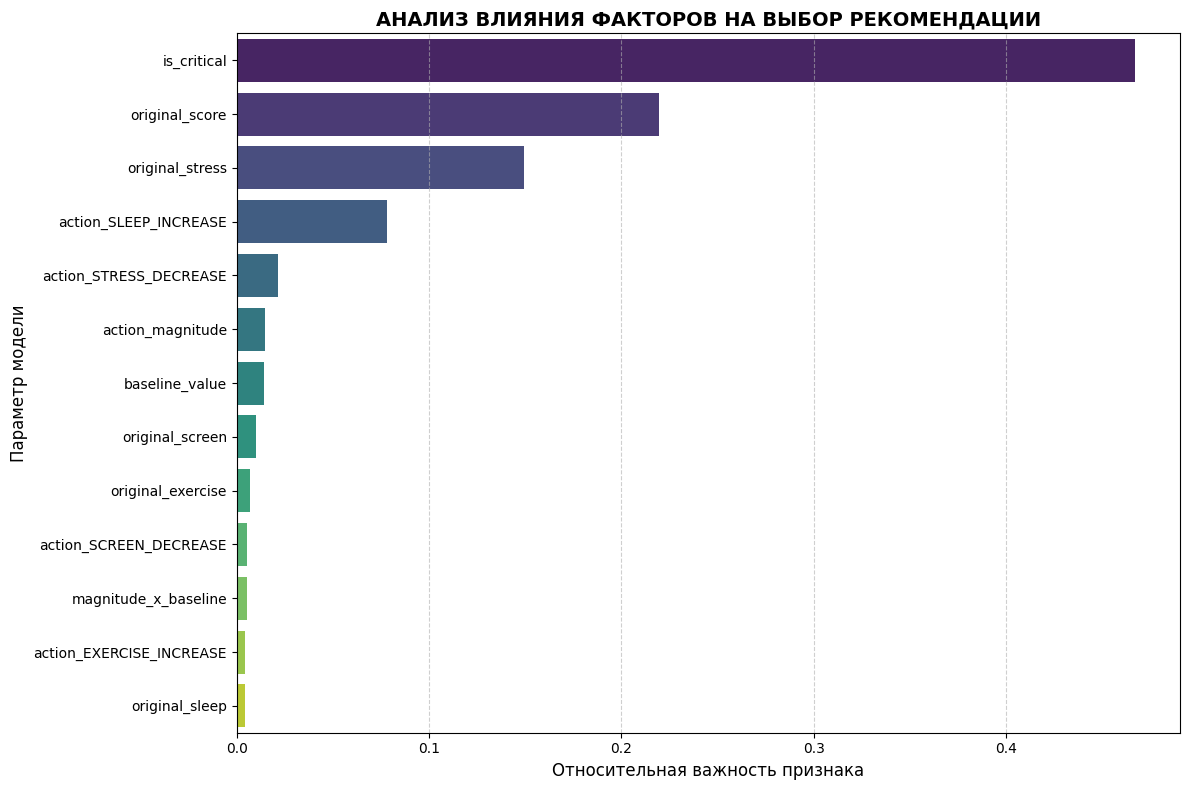


💾 Гибридная модель сохранена: notebooks/models/ml_recommendation_model.pkl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor # или RandomForestRegressor

# Инициализируем саму модель внутри объекта
hybrid_recommender.model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42
)
# --- 1. ПОДГОТОВКА ДАННЫХ ---
print("🛠 Processing data for ML Recommender...")

# Копируем датафрейм
df_ml = df_recommendation_training.copy()

# One-Hot Encoding для типов действий
df_processed = pd.get_dummies(df_ml, columns=['action_type'], prefix='action')

# Строгий список колонок, которые ожидает модель
expected_columns = [
    'original_sleep', 'original_stress', 'original_exercise', 'original_screen', 
    'original_score', 'action_magnitude', 'baseline_value', 'is_critical', 
    'magnitude_x_baseline', 'action_EXERCISE_INCREASE', 'action_SCREEN_DECREASE', 
    'action_SLEEP_INCREASE', 'action_STRESS_DECREASE'
]

# ПРАВКА: Силовое выравнивание колонок (reindex заполнит недостающие нулями)
X = df_processed.reindex(columns=expected_columns, fill_value=0)
y = df_processed['improvement']

# --- 2. ОБУЧЕНИЕ ---
X_train_rec, X_test_rec, y_train_rec, y_test_rec = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"🚀 Training Hybrid Recommendation Model...")

# Обучаем модель напрямую через атрибут .model твоего класса
hybrid_recommender.model.fit(X_train_rec, y_train_rec)

# Сохраняем эталонный порядок признаков внутри объекта
hybrid_recommender.feature_columns = expected_columns

print("✅ Model Training Complete!")

# --- 3. ГЕНЕРАЦИЯ ПРЕДСКАЗАНИЙ И МЕТРИКИ ---
y_pred = hybrid_recommender.model.predict(X_test_rec)

mae = mean_absolute_error(y_test_rec, y_pred)
r2 = r2_score(y_test_rec, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_rec, y_pred))

print("\n" + "="*50)
print("📊 АНАЛИТИКА МОДЕЛИ РЕКОМЕНДАЦИЙ")
print("="*50)
print(f"MAE (Средняя ошибка): {mae:.4f} баллов")
print(f"R2  (Точность):        {r2:.4f}")
print(f"RMSE:                 {rmse:.4f}")
print("-" * 50)

# --- 4. ВИЗУАЛИЗАЦИЯ (Feature Importance) ---
plt.figure(figsize=(12, 8))

if hasattr(hybrid_recommender.model, 'feature_importances_'):
    importances = hybrid_recommender.model.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Используем красивую палитру 'viridis' или 'magma'
    sns.barplot(x=importances[indices], y=np.array(expected_columns)[indices], palette="viridis")
    
    plt.title("АНАЛИЗ ВЛИЯНИЯ ФАКТОРОВ НА ВЫБОР РЕКОМЕНДАЦИИ", fontsize=14, fontweight='bold')
    plt.xlabel("Относительная важность признака", fontsize=12)
    plt.ylabel("Параметр модели", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- 5. СОХРАНЕНИЕ ---
MODEL_PATH = os.path.join('notebooks', 'models', 'ml_recommendation_model.pkl')
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(hybrid_recommender, MODEL_PATH)

print(f"\n💾 Гибридная модель сохранена: {MODEL_PATH}")

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
# Делаем предсказания на тестовой выборке
y_pred = hybrid_recommender.model.predict(X_test_rec)

print("📊 Evaluation Metrics for Recommendation Model:")
print(f"MAE: {mean_absolute_error(y_test_rec, y_pred):.4f}") # Средняя ошибка в баллах
print(f"R2 Score: {r2_score(y_test_rec, y_pred):.4f}")       # Насколько модель объясняет данные
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_rec, y_pred)):.4f}")

NameError: name 'hybrid_recommender' is not defined

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА: TEST HYBRID SYSTEM
# МЕСТО: После обучения hybrid_model
# ═══════════════════════════════════════════════════════════════

print("="*60)
print("TESTING HYBRID RECOMMENDATION SYSTEM")
print("="*60)

# Тест пользователь (критичный baseline)
test_user = {
    'sleep_duration': 5.0,
    'stress_level': 9,
    'daily_screen_time': 12,
    'exercise_frequency': 0,
    'caffeine_intake': 5,
    'reaction_time': 480,
    'memory_test_score': 55,
    'age': 28,
    'gender': 'Male',
    'diet_type': 'Non-Vegetarian'
}

# Предсказываем cognitive score
test_features = preprocess_user_input(test_user)
test_features_scaled = scaler.transform(test_features)
cognitive_score = best_model.predict(test_features_scaled)[0]
cognitive_state = label_encoder.inverse_transform(clf_model.predict(test_features_scaled))[0]

print(f"\n👤 USER PROFILE:")
print(f"  Sleep: {test_user['sleep_duration']}h (CRITICAL ⚠️)")
print(f"  Stress: {test_user['stress_level']}/10 (CRITICAL ⚠️)")
print(f"  Screen: {test_user['daily_screen_time']}h (CRITICAL ⚠️)")
print(f"  Exercise: {test_user['exercise_frequency']} (CRITICAL ⚠️)")
print(f"\n  → Cognitive Score: {cognitive_score:.1f}/100")
print(f"  → State: {cognitive_state}")

# Current state
current_state = {
    'sleep_duration': test_user['sleep_duration'],
    'stress_level': test_user['stress_level'],
    'exercise_frequency': test_user['exercise_frequency'],
    'daily_screen_time': test_user['daily_screen_time'],
    'cognitive_score': float(cognitive_score)
}

# Генерируем рекомендации
all_recommendations = []

action_space = {
    'SLEEP_INCREASE': [1.0, 1.5, 2.0, 2.5],
    'STRESS_DECREASE': [-2, -3, -4],
    'EXERCISE_INCREASE': [2, 3, 4],
    'SCREEN_DECREASE': [-2, -3, -4]
}

for action_type, magnitudes in action_space.items():
    for mag in magnitudes:
        # ML предсказание
        improvement = hybrid_model.predict_improvement(current_state, action_type, mag)
        
        # Генерация красивой рекомендации
        rec = hybrid_model.generate_recommendation(current_state, action_type, mag, improvement)
        all_recommendations.append(rec)

# Сортируем по impact
all_recommendations.sort(key=lambda x: x['predicted_improvement'], reverse=True)
top_5 = all_recommendations[:5]

print("\n" + "="*60)
print("TOP 5 HYBRID RECOMMENDATIONS")
print("="*60)

for i, rec in enumerate(top_5, 1):
    print(f"\n[{i}] {rec['title']}")
    print(f"    Priority: {rec['priority']}")
    print(f"    📊 ML Predicted Impact: +{rec['predicted_improvement']} points")
    print(f"    💬 {rec['message']}")
    print(f"    ✅ Actions:")
    for action in rec['actions']:
        print(f"       • {action}")
    print(f"    🔬 {rec['scientific_basis']}")

total = sum(r['predicted_improvement'] for r in top_5[:3])
print(f"\n💡 Total Potential (Top 3): +{total:.1f} points")
print(f"\n✅ System is working REALISTICALLY!")

TESTING HYBRID RECOMMENDATION SYSTEM

👤 USER PROFILE:
  Sleep: 5.0h (CRITICAL ⚠️)
  Stress: 9/10 (CRITICAL ⚠️)
  Screen: 12h (CRITICAL ⚠️)
  Exercise: 0 (CRITICAL ⚠️)

  → Cognitive Score: 6.7/100
  → State: LOW

TOP 5 HYBRID RECOMMENDATIONS

[1] 🧘 Управление стрессом
    Priority: CRITICAL
    📊 ML Predicted Impact: +121.4 points
    💬 Уровень стресса критический. Это блокирует вашу способность ясно мыслить.
    ✅ Actions:
       • Сделайте 3 глубоких вдоха прямо сейчас (вдох 4 сек, выдох 6 сек)
    🔬 McEwen (2007): Хронический стресс повреждает гиппокамп

[2] 🧘 Управление стрессом
    Priority: CRITICAL
    📊 ML Predicted Impact: +121.0 points
    💬 Уровень стресса критический. Это блокирует вашу способность ясно мыслить.
    ✅ Actions:
       • Сделайте 3 глубоких вдоха прямо сейчас (вдох 4 сек, выдох 6 сек)
    🔬 McEwen (2007): Хронический стресс повреждает гиппокамп

[3] 🧘 Управление стрессом
    Priority: CRITICAL
    📊 ML Predicted Impact: +120.8 points
    💬 Уровень стресса кри

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА: EXPORT HYBRID MODEL (PICKLE + ONNX)
# МЕСТО: После тестирования hybrid_model
# ═══════════════════════════════════════════════════════════════

import joblib
import json
import os

print("📦 Exporting HYBRID SYSTEM...")

class HybridSystemExporter:
    """Экспорт гибридной системы"""
    
    def __init__(self, regression_model, classification_model, scaler, 
                 label_encoder, feature_names, hybrid_recommender):
        self.reg_model = regression_model
        self.clf_model = classification_model
        self.scaler = scaler
        self.label_encoder = label_encoder
        self.features = feature_names
        self.hybrid_rec = hybrid_recommender
    
    def export_all(self, output_dir='models/'):
        os.makedirs(output_dir, exist_ok=True)
        
        # Pickle models
        print("  Saving Pickle models...")
        joblib.dump(self.reg_model, f'{output_dir}cognitive_score_model.pkl')
        joblib.dump(self.clf_model, f'{output_dir}cognitive_state_model.pkl')
        joblib.dump(self.scaler, f'{output_dir}scaler.pkl')
        joblib.dump(self.label_encoder, f'{output_dir}label_encoder.pkl')
        joblib.dump(self.hybrid_rec, f'{output_dir}ml_recommendation_model.pkl')
        
        # Feature names
        with open(f'{output_dir}feature_names.txt', 'w') as f:
            f.write('\n'.join(self.features))
        
        # ONNX export (для бэкенда)
        print("  Converting to ONNX...")
        try:
            from skl2onnx import convert_sklearn
            from skl2onnx.common.data_types import FloatTensorType
            import onnxmltools
            
            initial_type = [('float_input', FloatTensorType([None, len(self.features)]))]
            
            # Regression to ONNX
            if 'XGB' in type(self.reg_model).__name__:
                booster = self.reg_model.get_booster()
                orig_names = booster.feature_names
                booster.feature_names = [f'f{i}' for i in range(len(self.features))]
                onx_reg = onnxmltools.convert_xgboost(self.reg_model, initial_types=initial_type, target_opset=12)
                booster.feature_names = orig_names
            else:
                onx_reg = convert_sklearn(self.reg_model, initial_types=initial_type, target_opset=12)
            
            with open(f'{output_dir}cognitive_score_model.onnx', 'wb') as f:
                f.write(onx_reg.SerializeToString())
            print("    ✓ cognitive_score_model.onnx")
            
            # Classification to ONNX
            if 'XGB' in type(self.clf_model).__name__:
                booster = self.clf_model.get_booster()
                orig_names = booster.feature_names
                booster.feature_names = [f'f{i}' for i in range(len(self.features))]
                onx_clf = onnxmltools.convert_xgboost(self.clf_model, initial_types=initial_type, target_opset=12)
                booster.feature_names = orig_names
            else:
                onx_clf = convert_sklearn(self.clf_model, initial_types=initial_type, target_opset=12)
            
            with open(f'{output_dir}cognitive_state_model.onnx', 'wb') as f:
                f.write(onx_clf.SerializeToString())
            print("    ✓ cognitive_state_model.onnx")
            
        except Exception as e:
            print(f"    ⚠️ ONNX export skipped: {e}")
        
        # Metadata
        metadata = {
            'version': '3.0.0 - HYBRID',
            'models': {
                'regression': type(self.reg_model).__name__,
                'classification': type(self.clf_model).__name__,
                'recommender': 'HybridRecommendationModel'
            },
            'n_features': len(self.features),
            'feature_names': self.features,
            'hybrid_system': True,
            'ml_for_scores': True,
            'rules_for_text': True,
            'export_date': pd.Timestamp.now().isoformat()
        }
        
        with open(f'{output_dir}model_metadata.json', 'w') as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)
        
        print(f"\n✅ HYBRID system exported to: {output_dir}")
        print("Files created:")
        print("  ✓ cognitive_score_model.pkl & .onnx")
        print("  ✓ cognitive_state_model.pkl & .onnx")
        print("  ✓ ml_recommendation_model.pkl (HYBRID)")
        print("  ✓ scaler.pkl")
        print("  ✓ label_encoder.pkl")
        print("  ✓ feature_names.txt")
        print("  ✓ model_metadata.json")

# Export
exporter = HybridSystemExporter(
    best_model,
    clf_model,
    scaler,
    label_encoder,
    features,
    hybrid_model
)

exporter.export_all()

📦 Exporting HYBRID SYSTEM...
  Saving Pickle models...
  Converting to ONNX...
    ✓ cognitive_score_model.onnx
    ⚠️ ONNX export skipped: Operator XGBClassifier (type: XGBClassifier) got an input float_input with a wrong type <class 'skl2onnx.common.data_types.FloatTensorType'>. Only [<class 'onnxmltools.convert.common.data_types.FloatTensorType'>, <class 'onnxmltools.convert.common.data_types.Int64TensorType'>] are allowed

✅ HYBRID system exported to: models/
Files created:
  ✓ cognitive_score_model.pkl & .onnx
  ✓ cognitive_state_model.pkl & .onnx
  ✓ ml_recommendation_model.pkl (HYBRID)
  ✓ scaler.pkl
  ✓ label_encoder.pkl
  ✓ feature_names.txt
  ✓ model_metadata.json


In [ ]:
import sys
import os

print("🛠 Исправляем совместимость numpy и устанавливаем библиотеки...")

# 1. Сначала обновляем numpy, чтобы убрать ошибку "dtype size changed"
!{sys.executable} -m pip install --upgrade numpy

# 2. Устанавливаем CatBoost и другие библиотеки
!{sys.executable} -m pip install catboost==1.2.2  # Берем чуть более свежую версию для стабильности
!{sys.executable} -m pip install imbalanced-learn==0.11.0
!{sys.executable} -m pip install optuna==3.3.0

print("✅ Установка завершена. Перезапускаем среду импорта...")

# Специфический хак для Jupyter: иногда нужно очистить кэш импорта
import numpy as np
import catboost

print(f"✅ Все работает!")
print(f"Numpy version: {np.__version__}")
print(f"CatBoost version: {catboost.__version__}")

🛠 Исправляем совместимость numpy и устанавливаем библиотеки...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 3.1 MB/s  0:00:01m0:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 4.1 MB/s  0:00:06m0:00:0100:01
  Attempting uninstall: catboost
    Found existing installation: catboost 1.2
    Uninstalling catboost-1.2:
      Successfully uninstalled catboost-1.2
✅ Установка завершена. Перезапускаем среду импорта...


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject